In [1]:
import numpy as np 
import math
import matplotlib.pyplot as plt 
%matplotlib  inline 

In [2]:
def f(x): 
    return 5*x**2 - 7*x+2



why are we doing this?

Micrograd is about understanding **derivatives and gradients**.

We first need a mathematical function so that we can later calculate its derivative and see how Micrograd performs automatic differentiation.
    

In [3]:
f(3)

26

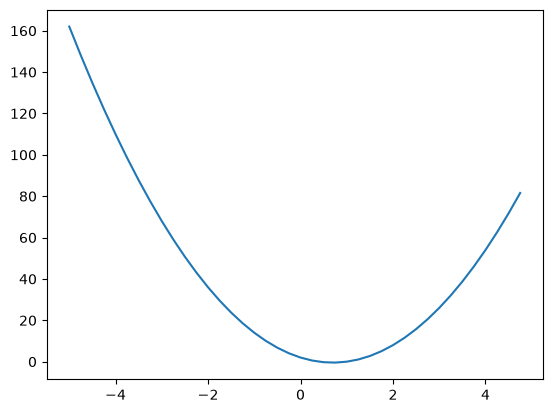

In [4]:
xs = np.arange(-5,5,0.25)
ys = f(xs)
plt.plot(xs,ys)

Why are we doing this?

We want to **visualize the function** before working with derivatives and Micrograd.

Later, we will use similar functions to understand how changing an input affects the output.


In [5]:
h = 0.000000001
x = 3
(f(x+h)-f(x))/h


23.000001903028533

In [6]:
h = 0.000000001
x = 7/10
(f(x+h)-f(x))/h

0.0

In [7]:
# lets get some more complex data 
a = 4.0
b = -5.0
c = 25 

d = a*b + c
print(d)


5.0


In [8]:
h = 0.00001

# inputs 
a = 4.0
b = -5.0
c = 25 

d1 = a*b + c
a = a+h
d2 = a*b + c

print("d1",d1)
print("d2",d2)
print("slope",(d2-d1)/h)

d1 5.0
d2 4.999950000000002
slope -4.999999999810711


In [9]:
h = 0.00001

# inputs 
a = 4.0
b = -5.0
c = 25 

d1 = a*b + c
b = b+h
d2 = a*b + c

print("d1",d1)
print("d2",d2)
print("slope",(d2-d1)/h)

d1 5.0
d2 5.0000399999999985
slope 3.9999999998485687


In [10]:
class value :
    def __init__(self,data):
        self.data = data 
    def __repr__(self):
        return f"value(data={self.data})"    # data is a number 


    def __add__(self,other): # doing it becoz python does not know how to add two values 
        out = value(self.data + other.data)   
        return out 

    # simillarly doing for multiplication 
    def __mul__(self,other):
        out = value(self.data * other.data)
        return out    

a = value(4.0)      
b = value(-5.0)
c = value(25)
d = a*b+c # it will internally calls like : (a.__mul__(b)).__add__(c)
d

value(data=5.0)

# ##. Creating the `Value` Class

## Code

    class Value:
        def __init__(self, data):
            self.data = data

        def __repr__(self):
            return f"Value(data={self.data})"

## What are we doing?

We are creating a class called `Value`.

This class will become the **basic building block of Micrograd**.

Instead of working with normal numbers like:

    a = 4.0

Micrograd will eventually use:

    a = Value(4.0)

The `Value` object will later store not only the number, but also information needed for **gradients and backpropagation**.

---

## 1. `class Value:`

    class Value:

`class` is used to create a new type of object.

Here, we create our own type called `Value`.

Think of it as a container that will hold a number and, later, its gradient and other information.

---

## 2. `__init__()`

    def __init__(self, data):

`__init__()` is a special Python method.

It runs automatically when we create a new `Value`.

For example:

    a = Value(4.0)

Python automatically calls:

    __init__(self, 4.0)

---

## 3. `self.data = data`

    self.data = data

This stores the actual numerical value inside the `Value` object.

For example:

    a = Value(4.0)

Then:

    a.data

gives:

    4.0

So:

    Value object
        ↓
    data = 4.0

---

## 4. `__repr__()`

    def __repr__(self):
        return f"Value(data={self.data})"

`__repr__()` controls how the object is displayed when we print it or inspect it.

For example:

    a = Value(4.0)

Without `__repr__()`, Python may display something like:

    <Value object at 0x...>

With `__repr__()`, it displays:

    Value(data=4.0)

This makes the object easier to understand while developing Micrograd.

---

## 5. Why `__init__` and `__repr__` have double underscores?

These are Python **special methods**, also called **dunder methods**.

`dunder` means:

    double underscore

Therefore, the correct names are:

    __init__()
    __repr__()

NOT:

    _init_()
    _repr_()

---

## Example

    a = Value(4.0)

Now:

    a.data

returns:

    4.0

And:

    print(a)

displays:

    Value(data=4.0)

---

## Why are we creating `Value`?

Currently, `Value` only stores a number.

But later we will expand it to store:

    Value
      ├── data
      ├── gradient
      ├── previous values
      └── operation

This information will allow Micrograd to build a **computation graph** and perform **backpropagation automatically**.

## Key Takeaway

`Value` is the basic object of Micrograd.

For now, it simply stores a number:

    Value(4.0)
        ↓
    data = 4.0

Later, we will add everything needed to calculate gradients automatically.

In [11]:
# more clearler visulization :

class value :
    def __init__(self,data, _children=(),_op='',label=''):
        self.data = data 
        self._prev = set(_children)
        self._op = _op
        self.label = label
        self.grad = 0.0
    def __repr__(self):
        return f"value(data={self.data})"    # data is a number 


    def __add__(self,other): # doing it becoz python does not know how to add two values 
        out = value(self.data + other.data,(self,other),'+')   
        return out 

    # simillarly doing for multiplication 
    def __mul__(self,other):
        out = value(self.data * other.data,(self,other),'*')
        return out  
##
    def __neg__(self):
        return self * value(-1)

                    ## doing this for substraction . 

    def __sub__(self, other):
        return self + (-other)  
##
    def __pow__(self, other):
        assert isinstance(other, (int, float))    ## FOR power value(2)**2 = value(4)
        out = value(self.data ** other, (self,), f'**{other}')
        return out
#3
# Activating tanh() function 

    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1) / (math.exp(2*x) + 1)
        out = value(t, (self,), 'tanh')
        return out

    # def _backward():
    #     self.grad += (1 - t**2) * out.grad
    #     out._backward = _backward
    #     return out

a = value(4.0,label = 'a')      
b = value(-5.0,label = 'b')
c = value(25, label ='c')

e= a*b ; e.label = 'e'

d = e +c ; d.label = 'd' # it will internally calls like : (a.__mul__(b)).__add__(c)
f = value(-2.0,label ='f')
L = d*f ; L.label = 'L'
L

value(data=-10.0)

# Complete Explanation — Building a Computation Graph in Micrograd

This code creates a custom `value` class that can:

1. Store numbers.
2. Remember previous values.
3. Remember which operation created a value.
4. Store labels for visualization.
5. Store a place for gradients.
6. Perform addition and multiplication between `value` objects.

---

# 1. Creating the `value` class

    class value:

We create our own class called `value`.

Instead of working directly with normal Python numbers like:

    a = 4.0

we will use:

    a = value(4.0)

This allows us to store not only the number but also information about how it was calculated.

---

# 2. The `__init__()` function

    def __init__(self, data, _children=(), _op='', label=''):

`__init__()` runs automatically whenever we create a new `value`.

For example:

    a = value(4.0, label='a')

The arguments are:

    data       → actual numerical value
    _children  → previous values used to create this value
    _op        → operation used to create this value
    label      → name of the value

The default values are:

    _children = ()
    _op = ''
    label = ''

This means we don't have to provide them every time.

---

# 3. `self.data`

    self.data = data

Stores the actual numerical value.

For example:

    a = value(4.0)

Then:

    a.data

is:

    4.0

Similarly:

    b = value(-5.0)

means:

    b.data = -5.0

---

# 4. `self._prev`

    self._prev = set(_children)

`_prev` stores the values that were used to create the current value.

For example, when we calculate:

    e = a * b

`e` was created using `a` and `b`.

Therefore:

    e._prev

contains:

    {a, b}

Why do we need this?

Because later Micrograd needs to know the previous values so it can move **backward through the computation graph** during backpropagation.

`set()` is used so that the values are stored as a unique collection.

---

# 5. `self._op`

    self._op = _op

Stores the operation that created the value.

For example:

    e = a * b

Then:

    e._op

is:

    '*'

For:

    d = e + c

we have:

    d._op

as:

    '+'

So Micrograd knows what operation produced each value.

---

# 6. `self.label`

    self.label = label

Stores a name for the value.

For example:

    a = value(4.0, label='a')

Then:

    a.label

is:

    'a'

The label is mainly useful when **visualizing the computation graph**.

---

# 7. `self.grad`

    self.grad = 0.0

Creates a variable to store the gradient of this value.

Currently, we are not calculating gradients yet, so every gradient starts at:

    0.0

Later, during backpropagation, these values will be updated.

---

# 8. `__repr__()` function

    def __repr__(self):
        return f"value(data={self.data})"

`__repr__()` controls how our object is displayed in Python.

For example:

    a = value(4.0)

If we write:

    a

Python displays:

    value(data=4.0)

instead of showing a confusing object address.

---

# 9. `__add__()` — defining addition

    def __add__(self, other):

This function tells Python how to add two `value` objects.

Normally Python knows how to do:

    4 + 5

But Python does not automatically know how to do:

    value(4) + value(5)

So we define `__add__()` ourselves.

---

# 10. Inside `__add__()`

    out = value(self.data + other.data, (self, other), '+')

Let's break this down.

Suppose:

    a = value(4.0)
    b = value(-5.0)

and we write:

    e = a + b

Here:

    self = a
    other = b

So:

    self.data = 4.0
    other.data = -5.0

The calculation becomes:

    4.0 + (-5.0) = -1.0

A new `value` object is created:

    out = value(-1.0, (a, b), '+')

This new value remembers:

    data      = -1.0
    children  = a, b
    operation = +

---

# 11. Returning `out`

    return out

The newly created value is returned.

So:

    e = a + b

means `e` receives the new `value` object.

---

# 12. `__mul__()` — defining multiplication

    def __mul__(self, other):

This function tells Python how to multiply two `value` objects.

Normally:

    4 * 5

works automatically.

But:

    value(4) * value(5)

needs our custom `__mul__()` function.

---

# 13. Inside `__mul__()`

    out = value(self.data * other.data, (self, other), '*')

Suppose:

    a = value(4.0)
    b = value(-5.0)

Then:

    a * b

becomes:

    4.0 * (-5.0) = -20.0

A new value is created:

    out = value(-20.0, (a, b), '*')

So `out` remembers:

    data      = -20.0
    children  = a, b
    operation = *

---

# 14. Creating `a`, `b`, and `c`

    a = value(4.0, label='a')
    b = value(-5.0, label='b')
    c = value(25, label='c')

We create three input values:

    a = 4
    b = -5
    c = 25

Their labels are:

    a → 'a'
    b → 'b'
    c → 'c'

---

# 15. Creating `e`

    e = a * b
    e.label = 'e'

First:

    a * b

calls:

    a.__mul__(b)

Calculation:

    4 × (-5) = -20

Therefore:

    e.data = -20

And `e` remembers:

    e._prev = {a, b}
    e._op = '*'
    e.label = 'e'

The graph is:

    a (4) ──┐
            × ──> e (-20)
    b (-5) ─┘

---

# 16. Creating `d`

    d = e + c
    d.label = 'd'

First:

    e + c

calls:

    e.__add__(c)

Calculation:

    -20 + 25 = 5

Therefore:

    d.data = 5

And `d` remembers:

    d._prev = {e, c}
    d._op = '+'
    d.label = 'd'

Now the graph is:

    a ──┐
        × ──> e ──┐
    b ──┘         + ──> d
                  │
    c ────────────┘

---

# 17. Creating `f`

    f = value(-2.0, label='f')

We create another input:

    f = -2

with the label:

    'f'

---

# 18. Creating the final output `L`

    L = d * f
    L.label = 'L'

Now:

    d = 5
    f = -2

So:

    L = 5 × (-2)
    L = -10

Therefore:

    L.data = -10

The final computation graph is:

    a (4) ──┐
            × ──> e (-20) ──┐
    b (-5) ─┘               +
                            ├──> d (5) ──┐
    c (25) ─────────────────┘           × ──> L (-10)
                                        │
    f (-2) ─────────────────────────────┘

---

# 19. What does this comment mean?

    d = e + c  # it will internally calls like:
               # (a.__mul__(b)).__add__(c)

The original expression:

    d = e + c

is actually based on the earlier calculation:

    e = a * b

So the complete calculation is:

    d = (a * b) + c

Python roughly performs:

    e = a.__mul__(b)
    d = e.__add__(c)

Then:

    L = d * f

uses:

    d.__mul__(f)

---

# 20. Final calculation

The mathematical expression represented by the code is:

    L = (a × b + c) × f

Substituting the values:

    L = (4 × -5 + 25) × -2

    L = (-20 + 25) × -2

    L = 5 × -2

    L = -10

So:

    L.data

gives:

    -10.0

---

# 21. The most important idea

The class is doing more than simply calculating numbers.

It is creating a **computation graph**.

Each value remembers:

    data → what is the value?
    _prev → which values created it?
    _op → which operation created it?
    label → what should we call it?
    grad → where will we store its gradient?

The graph is:

    a ──┐
        × ──> e ──┐
    b ──┘         │
                  + ──> d ──┐
    c ────────────┘         │
                            × ──> L
    f ──────────────────────┘

This graph is the foundation of **automatic differentiation**.

## Key Takeaway

The code calculates:

    L = (a × b + c) × f = -10

But more importantly, it **remembers every step used to calculate -10**.

That stored calculation history will allow Micrograd to later calculate gradients automatically using **backpropagation**.

In [12]:
L._prev

{value(data=-2.0), value(data=5.0)}

In [13]:
L._op

'*'

## # graphical representation 

graphviz is open source graph visualization software 

In [14]:
from graphviz import Digraph

def trace(root):
    # builds a set of all nodes and edges in a graph
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
    
    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        # for any value in the graph, create a rectangular ('record') node for it
        dot.node(name=uid, label="{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
        if n._op:
            # if this value is a result of some operation, create an op node for it
            dot.node(name=uid + n._op, label=n._op)
            # and connect this node to it
            dot.edge(uid + n._op, uid)

    for n1, n2 in edges:
        # connect n1 to the op node of n2
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot

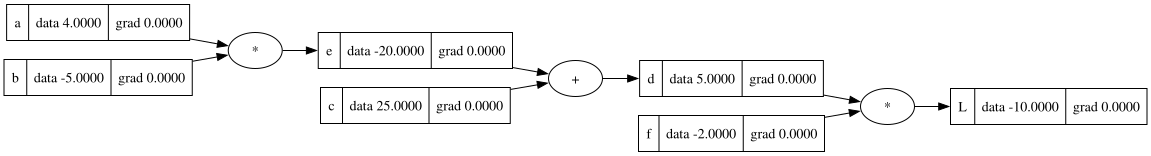

In [15]:
draw_dot(L)

In [16]:
L.grad = 1.00
f.grad = 5.00
d.grad = -2.00

In [17]:
from graphviz import Digraph

def trace(root):
    # builds a set of all nodes and edges in a graph
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
    
    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        # for any value in the graph, create a rectangular ('record') node for it
        dot.node(name=uid, label="{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
        if n._op:
            # if this value is a result of some operation, create an op node for it
            dot.node(name=uid + n._op, label=n._op)
            # and connect this node to it
            dot.edge(uid + n._op, uid)

    for n1, n2 in edges:
        # connect n1 to the op node of n2
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot

# Backprpogation ( doing dervatives )

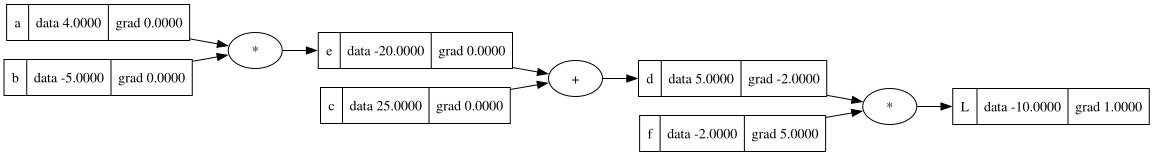

In [18]:
draw_dot(L)

## #dL/df

In [19]:
def lol():
    h = 0.00001
    a = value(4.0,label = 'a')      
    b = value(-5.0,label = 'b')
    c = value(25, label ='c')

    e= a*b ; e.label = 'e'

    d = e + c ; d.label = 'd' # it will internally calls like : (a.__mul__(b)).__add__(c)
    f = value(-2.0,label ='f')
    L = d*f ; L.label = 'L'
    L1 = L.data

    a = value((4.0), label = 'a')
    b = value(-5.0,label = 'b')
    c = value(25,label = 'c')

    e = a*b ; e.label = 'e'
    d = e + c ; d.label = 'd'
    f = value(-2.0+h,label = 'f') # -2.0+h i.e.  taking derivatives with respect to f 

    L = d*f ; L.label = 'L'

    L2 = L.data

    print((L2-L1)/h) # ((f+h)-f)/h
lol()

4.999999999988347


## # dL/dd

In [20]:
def lol():
    h = 0.00001
    a = value(4.0,label = 'a')      
    b = value(-5.0,label = 'b')
    c = value(25, label ='c')

    e= a*b ; e.label = 'e'

    d = e + c ; d.label = 'd' # it will internally calls like : (a.__mul__(b)).__add__(c)
    f = value(-2.0,label ='f')
    L = d*f ; L.label = 'L'
    L1 = L.data

    a = value((4.0), label = 'a')
    b = value(-5.0,label = 'b')
    c = value(25,label = 'c')

    e = a*b ; e.label = 'e'
    d = e + c ; d.label = 'd'
    d.data +=h # d = d+h , 
    f = value(-2.0,label = 'f')

    L = d*f ; L.label = 'L'

    L2 = L.data

    print((L2-L1)/h) # ((d+h)-d)/h
lol()

-1.9999999999242843


In [21]:
def lol():
    h = 0.00001
    a = value(4.0,label = 'a')      
    b = value(-5.0,label = 'b')
    c = value(25, label ='c')

    e= a*b ; e.label = 'e'

    d = e + c ; d.label = 'd' # it will internally calls like : (a.__mul__(b)).__add__(c)
    f = value(-2.0,label ='f')
    L = d*f ; L.label = 'L'
    L1 = L.data

    a = value((4.0+h), label = 'a')
    b = value(-5.0,label = 'b')
    c = value(25,label = 'c')

    e = a*b ; e.label = 'e'
    d = e + c ; d.label = 'd'
    f = value(-2.0,label = 'f')

    L = d*f ; L.label = 'L'

    L2 = L.data

    print((L2-L1)/h)
lol()



    

    


9.999999999621423


# Numerical Gradient — Simple Explanation

The purpose of this code is to **check how much the final output `L` changes when we slightly change `a`**.

Our equation is:

    L = (a × b + c) × f

---

## 1. Create a very small change

    h = 0.00001

### Why?

We want to change `a` by a **very tiny amount**.

    a = 4
    a + h = 4.00001

This helps us measure how sensitive `L` is to `a`.

---

## 2. Calculate the original `L`

    a = value(4.0, label='a')
    b = value(-5.0, label='b')
    c = value(25, label='c')

    e = a * b
    d = e + c

    f = value(-2.0, label='f')
    L = d * f

    L1 = L.data

Calculation:

    e = 4 × (-5) = -20

    d = -20 + 25 = 5

    L = 5 × (-2) = -10

So:

    L1 = -10

### Why?

We need the **original output** so that we can compare it with the new output.

---

## 3. Increase `a` slightly

    a = value(4.0 + h, label='a')

Now:

    a = 4.00001

The other values stay the same.

### Why?

We want to see:

> "What happens to `L` if I make a tiny change to `a`?"

---

## 4. Calculate `L` again

    e = a * b
    d = e + c
    f = value(-2.0, label='f')
    L = d * f

    L2 = L.data

Now we get approximately:

    L2 = -9.9999

So:

    Before changing a:  L1 = -10
    After changing a:   L2 = -9.9999

---

## 5. Calculate the gradient

    print((L2 - L1) / h)

This is the **finite difference formula**:

    gradient ≈ (new output - old output) / change

So:

    dL/da ≈ (L2 - L1) / h

Result:

    ≈ 10

### Why?

This tells us how strongly `L` changes when `a` changes.

So we learned:

    dL/da ≈ 10

---

# Now Start Backpropagation

We have:

    L = d × f

and:

    d = 5
    f = -2

---

## 6. Start with `L.grad`

    L.grad = 1.0

### Why 1?

Because:

    dL/dL = 1

A value's derivative with respect to itself is always `1`.

This is where backpropagation starts.

---

## 7. Find `d.grad`

We have:

    L = d × f

Derivative with respect to `d`:

    dL/dd = f

We know:

    f = -2

Therefore:

    d.grad = -2

### Why?

If `d` changes by 1, `L` changes by `f`.

Since:

    f = -2

`L` changes by `-2`.

---

## 8. Find `f.grad`

For:

    L = d × f

Derivative with respect to `f`:

    dL/df = d

We know:

    d = 5

Therefore:

    f.grad = 5

### Why?

If `f` changes by 1, `L` changes by `d`.

Since:

    d = 5

`L` changes by `5`.

---

# Final Result

    L.grad = 1
    d.grad = -2
    f.grad = 5

Think of the process as:

    Forward:
    
    a → e → d → L
              ↑
              f

    Backward:

    L.grad = 1
       ↓
    d.grad = -2
    f.grad = 5

---

# Why are we doing all this?

We are preparing Micrograd for **automatic differentiation**.

First, we manually understand gradients:

    Numerical method
    → change a slightly
    → observe change in L
    → calculate dL/da

Then we start:

    Backpropagation
    → start at L
    → move backward
    → calculate gradients

Later, Micrograd will do this **automatically** for us.

# Key Takeaway

    (L2 - L1) / h
            ↓
    numerical gradient of a

    L.grad = 1
            ↓
    start backpropagation

    d.grad = -2
    f.grad = 5
            ↓
    move further backward through the graph

### # Now Crux of backpropogation 

In [22]:
from graphviz import Digraph

def trace(root):
    # builds a set of all nodes and edges in a graph
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
    
    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        # for any value in the graph, create a rectangular ('record') node for it
        dot.node(name=uid, label="{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
        if n._op:
            # if this value is a result of some operation, create an op node for it
            dot.node(name=uid + n._op, label=n._op)
            # and connect this node to it
            dot.edge(uid + n._op, uid)

    for n1, n2 in edges:
        # connect n1 to the op node of n2
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot

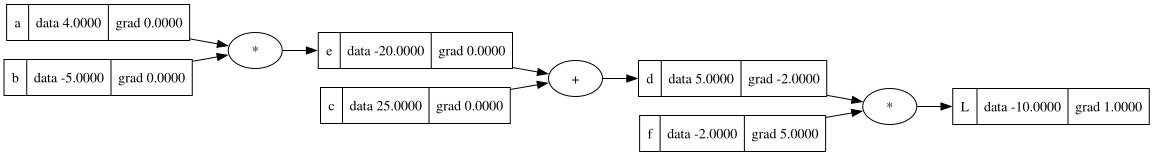

In [23]:
draw_dot(L)

In [24]:
from graphviz import Digraph

def trace(root):
    # builds a set of all nodes and edges in a graph
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
    
    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        # for any value in the graph, create a rectangular ('record') node for it
        dot.node(name=uid, label="{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
        if n._op:
            # if this value is a result of some operation, create an op node for it
            dot.node(name=uid + n._op, label=n._op)
            # and connect this node to it
            dot.edge(uid + n._op, uid)

    for n1, n2 in edges:
        # connect n1 to the op node of n2
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot

dd / dc ? 1.0

d = c + e

(f(x+h) - f(x)) / h

((c + h + e) - (c + e)) / h

(c + h + e - c - e) / h

h / h

1.0

# looking for local derivative i.e. , dL / dc and dL / de

# using chain rule 

dd/dc = 1 = dd / de 

WANT : 

dL / dc = (dL / dd) * (dd / dc)

dL / dc = (-2.0)*(1.0)

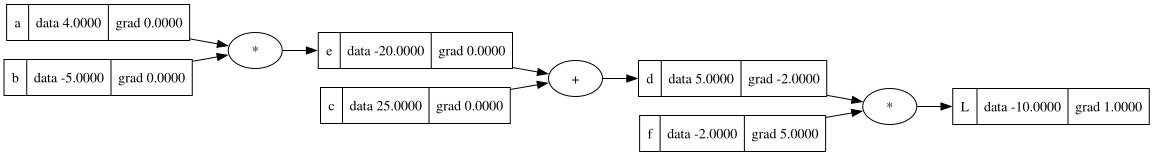

In [25]:
draw_dot(L)

In [26]:
c.grad = -2.0
e.grad = -2.0

In [27]:
# now checking via code of gradient descent of c.grad and e.grad 

# for c.grad

def lol():
    h = 0.00001
    a = value(4.0,label = 'a')      
    b = value(-5.0,label = 'b')
    c = value(25, label ='c')

    e= a*b ; e.label = 'e'

    d = e + c ; d.label = 'd' # it will internally calls like : (a.__mul__(b)).__add__(c)
    f = value(-2.0,label ='f')
    L = d*f ; L.label = 'L'
    L1 = L.data

    a = value((4.0), label = 'a')
    b = value(-5.0,label = 'b')
    c = value(25,label = 'c')
    c.data +=h # c = c+h 

    e = a*b ; e.label = 'e'

    d = e + c ; d.label = 'd'
    f = value(-2.0,label = 'f')

    L = d*f ; L.label = 'L'

    L2 = L.data

    print((L2-L1)/h) # dL / dc = ((c+h)-c)/h
    # simillarly for e, e.data +=h
lol()

-1.9999999999242843


# now again apply chain rule for grad. of 'a' and 'b'. 

we have dL / de = -2.0 

WANT : 

dL / da ? ;  #.             

 dL / da = (dL / de) * (de / da) 

as we have (dL/de) = -2.0

now finding (de / da ) ?

e = a * b 

e = ( 2.0 ) * ( -3.0 )

de / da ? ; b ( as we have done earlier )


so de / da = - 3.0 

hence dL / da = (dL / de ) * (de / da)

______dL / da =  ( -2.0 ) *  ( -3.0 ) __ = __ + 6

simillarly for 

______dL / db = ( -2.0 ) * ( 2.0 ) = -4.0 





In [28]:
from graphviz import Digraph

def trace(root):
    # builds a set of all nodes and edges in a graph
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
    
    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        # for any value in the graph, create a rectangular ('record') node for it
        dot.node(name=uid, label="{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
        if n._op:
            # if this value is a result of some operation, create an op node for it
            dot.node(name=uid + n._op, label=n._op)
            # and connect this node to it
            dot.edge(uid + n._op, uid)

    for n1, n2 in edges:
        # connect n1 to the op node of n2
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot

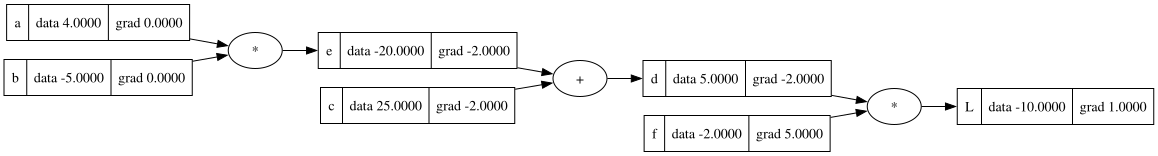

In [29]:
draw_dot(L)

In [30]:
a.grad = 6.0 
b.grad = -4.0 

In [31]:
# now checking via code of gradient descent of a.grad and b.grad 

# for a.grad

def lol():
    h = 0.00001
    a = value(4.0,label = 'a')      
    b = value(-5.0,label = 'b')
    c = value(25, label ='c')

    e= a*b ; e.label = 'e'

    d = e + c ; d.label = 'd' # it will internally calls like : (a.__mul__(b)).__add__(c)
    f = value(-2.0,label ='f')
    L = d*f ; L.label = 'L'
    L1 = L.data

    a = value((4.0), label = 'a')
    a.data +=h
    b = value(-5.0,label = 'b')
    c = value(25,label = 'c')
    # c.data +=h # c = c+h 

    e = a*b ; e.label = 'e'

    d = e + c ; d.label = 'd'
    f = value(-2.0,label = 'f')

    L = d*f ; L.label = 'L'

    L2 = L.data

    print((L2-L1)/h) # dL / dc = ((c+h)-c)/h
    # simillarly for e, e.data +=h
lol()

9.999999999621423


## Manual Backpropogation # example : 02

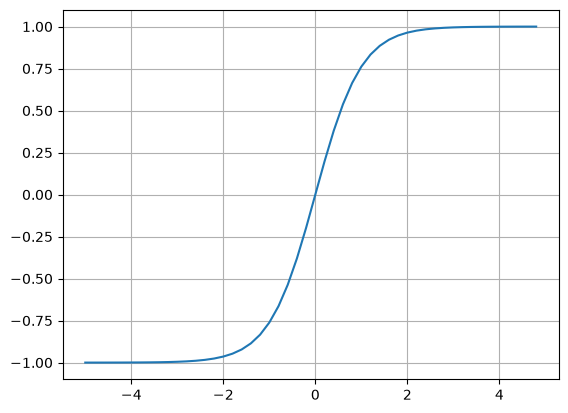

In [32]:
plt.plot(np.arange(-5,5,0.2), np.tanh(np.arange(-5,5,0.2))); plt.grid()

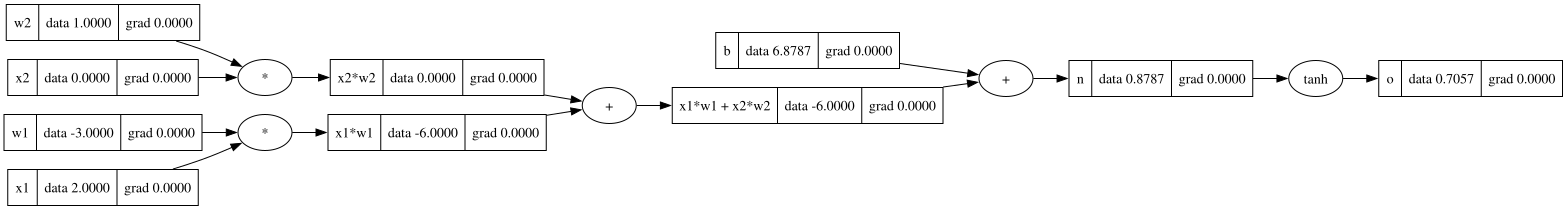

In [33]:
# input x1 and x2 
x1 = value(2.0, label='x1')
x2 = value(0.0, label='x2')

# weight w1 and w2 
w1 = value(-3.0, label='w1')
w2 = value(1.0, label='w2')

# bais of the neuron 
b  = value(6.8786564646, label='b')

# x1*w1 + x2*w2 + b
x1w1 = x1*w1;  x1w1.label = 'x1*w1'
x2w2 = x2*w2;  x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2 ; x1w1x2w2.label='x1*w1 + x2*w2'
n = x1w1x2w2 + b;  n.label = 'n'
o = n.tanh();      o.label = 'o'

draw_dot(o)

### Hyperbolic Tangent ,  # Tanh()

$$
\tanh(x) = \frac{e^{2x} - 1}{e^{2x} + 1}
$$

### Derivative of tanh

$$
\frac{d}{dx}\tanh(x) = 1 - \tanh^2(x)
$$

Since:

$$
t = \tanh(x)
$$

we can write:

$$
\frac{dt}{dx} = 1 - t^2
$$

### Backpropagation

$$
\frac{\partial L}{\partial x}
=
(1-t^2)
\frac{\partial L}{\partial t}
$$

---

### For Our Specific Example

We have:

$$
o = \tanh(n)
$$

Therefore:

$$
\frac{do}{dn}
=
\frac{d(\tanh(n))}{dn}
$$

Using the derivative of tanh:

$$
\frac{do}{dn}
=
1 - \tanh^2(n)
$$

Since:

$$
o = \tanh(n)
$$

therefore:

$$
\boxed{\frac{do}{dn} = 1 - o^2}
$$

For backpropagation:

$$
n.grad
=
(1-o^2) \times o.grad
$$

In [34]:
o.grad = 1 # as do / do = 1

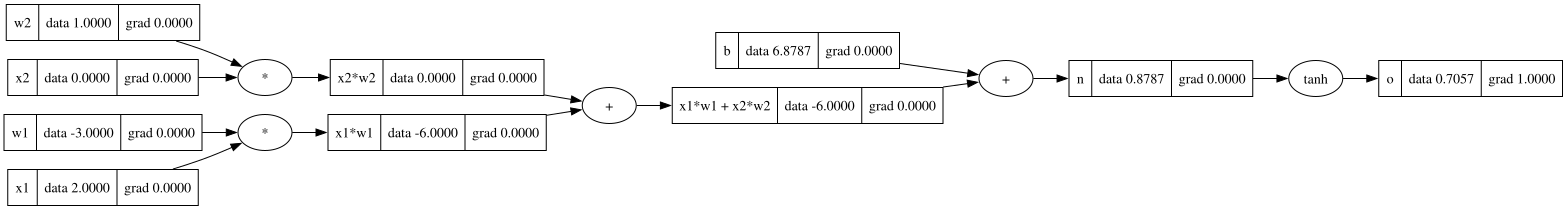

In [35]:
draw_dot(o)

For backpropagation:

$$
n.grad
=
(1-o^2) \times o.grad
$$


for n.grad __ i.e. __ do/dn 

In [36]:
o.data

0.7057456081105479

In [37]:
n.grad = (1 - o.data**2)*(1) # as o.grad = 1 
n.grad

0.501923136632673

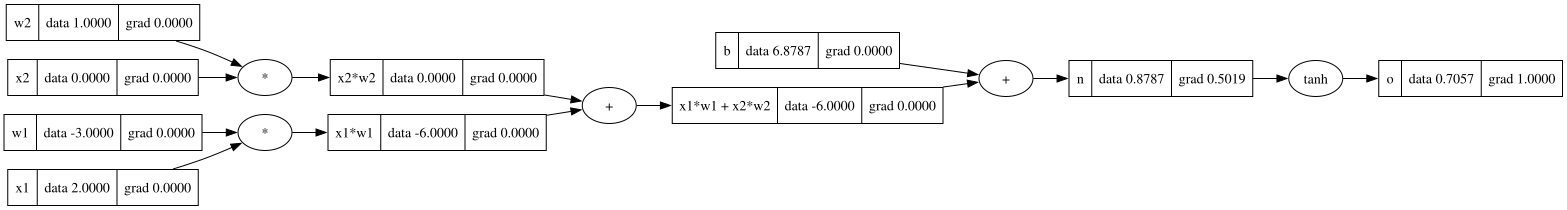

In [38]:
draw_dot(o)

In [39]:
# now for x1w1x2w2;
#. as we seen earlier for addition gradient is distributed equally so ; 

# as n = x1w1x2w2 + b and n.grad = 0.501923136632673 so ;

x1w1x2w2.grad = 0.501923136632673
b.grad = 0.501923136632673



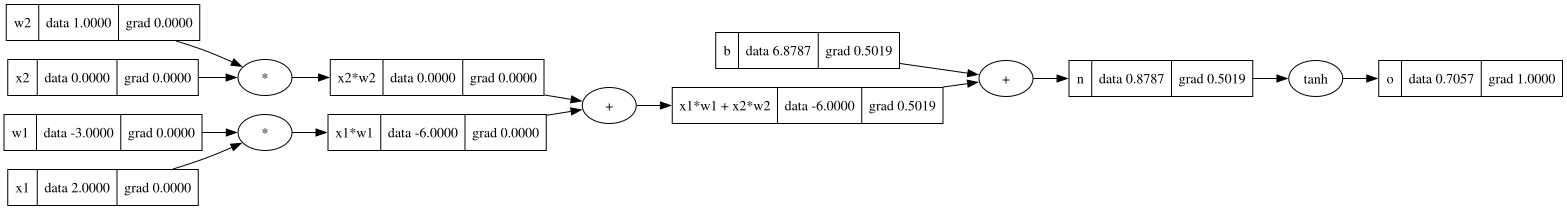

In [40]:
draw_dot(o)

In [41]:
# simillarly as x1w1x2w2 = x1w1 + x2w2 ; so ,grad will be equally distributed on them too 
x1w1.grad = 0.501923136632673
x2w2.grad = 0.501923136632673


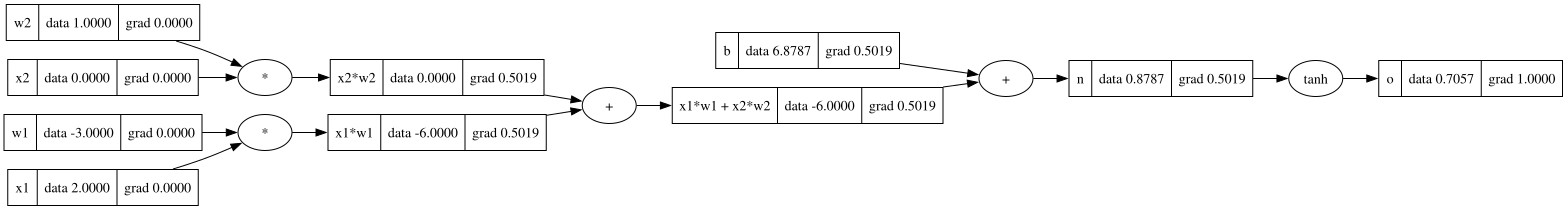

In [42]:
draw_dot(o)

### Backpropagation to `x1`

$$
\frac{do}{dx_2}
=
\frac{do}{dn}
\times
\frac{dn}{d(x_2w_2)}
\times
\frac{d(x_2w_2)}{dx_2}
$$

$$
\frac{do}{dx_2}
=
(1-o^2)\times1\times w_2
$$

Therefore:

$$
\boxed{x_2.grad = w_2.data\times x_2w_2.grad}
$$

---

### Backpropagation to `w2`

$$
\frac{do}{dw_2}
=
\frac{do}{dn}
\times
\frac{dn}{d(x_2w_2)}
\times
\frac{d(x_2w_2)}{dw_2}
$$

$$
\frac{do}{dw_2}
=
(1-o^2)\times1\times x_2
$$

Therefore:

$$
\boxed{w_2.grad = x_2.data\times x_2w_2.grad}
$$

$$
\boxed{x_2.grad = w_2.data \times x_2w_2.grad}
$$

$$
\boxed{w_2.grad = x_2.data \times x_2w_2.grad}
$$

In [43]:
x2.grad = w2.data * x2w2.grad
w2.grad = x2.data * x2w2.grad


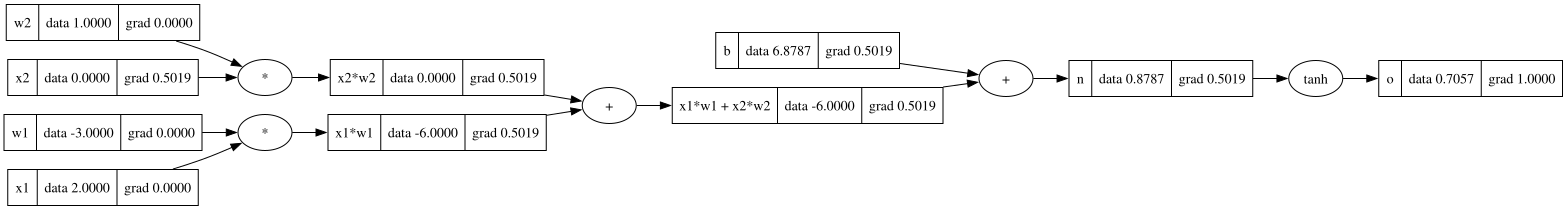

In [44]:
draw_dot(o)

# simillarly 
$$
\boxed{x_1.grad = w_1.data \times x_1w_1.grad}
$$

$$
\boxed{w_1.grad = x_1.data \times x_1w_1.grad}
$$

In [45]:
x1.grad = w1.data * x1w1.grad
w1.grad = x1.data * x1w1.grad


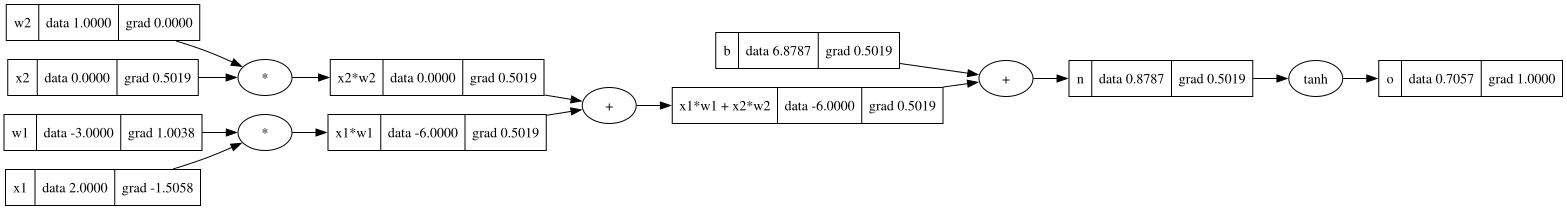

In [46]:
draw_dot(o)

# # Automatic Backpropogation 

In [47]:
class value :
    def __init__(self,data, _children=(),_op='',label=''):
        self.data = data 
        self._prev = set(_children)
        self._op = _op
        self.label = label
        self.grad = 0.0
        self._backward = lambda:None
    def __repr__(self):
        return f"value(data={self.data})"    # data is a number 


    def __add__(self,other): # doing it becoz python does not know how to add two values 
        out = value(self.data + other.data,(self,other),'+')   
        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad

        out._backward = _backward
        return out    

    # simillarly doing for multiplication 
    def __mul__(self,other):
        out = value(self.data * other.data,(self,other),'*')
        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * other.grad

        out._backward = _backward    
        return out    

# Activating tanh() function 
    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1) / (math.exp(2*x) + 1)
        out = value(t, (self,), 'tanh')

        def _backward():
            self.grad += (1-t**2) * out.grad
        out._backward = _backward   
        return out
# Automatic backpropogation 

    # def _backward():
    #     self.grad += (1 - t**2) * out.grad
    #     out._backward = _backward
    #     return out

a = value(4.0,label = 'a')      
b = value(-5.0,label = 'b')
c = value(25, label ='c')

e= a*b ; e.label = 'e'

d = e +c ; d.label = 'd' # it will internally calls like : (a.__mul__(b)).__add__(c)
f = value(-2.0,label ='f')
L = d*f ; L.label = 'L'
L

value(data=-10.0)

In [48]:
from graphviz import Digraph

def trace(root):
    # builds a set of all nodes and edges in a graph
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
    
    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        # for any value in the graph, create a rectangular ('record') node for it
        dot.node(name=uid, label="{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
        if n._op:
            # if this value is a result of some operation, create an op node for it
            dot.node(name=uid + n._op, label=n._op)
            # and connect this node to it
            dot.edge(uid + n._op, uid)

    for n1, n2 in edges:
        # connect n1 to the op node of n2
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot

In [49]:
# input x1 and x2 
x1 = value(2.0, label='x1')
x2 = value(0.0, label='x2')

# weight w1 and w2 
w1 = value(-3.0, label='w1')
w2 = value(1.0, label='w2')

# bais of the neuron 
b  = value(6.8786564646, label='b')

# x1*w1 + x2*w2 + b
x1w1 = x1*w1;  x1w1.label = 'x1*w1'
x2w2 = x2*w2;  x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2 ; x1w1x2w2.label='x1*w1 + x2*w2'
n = x1w1x2w2 + b;  n.label = 'n'
o = n.tanh();      o.label = 'o'


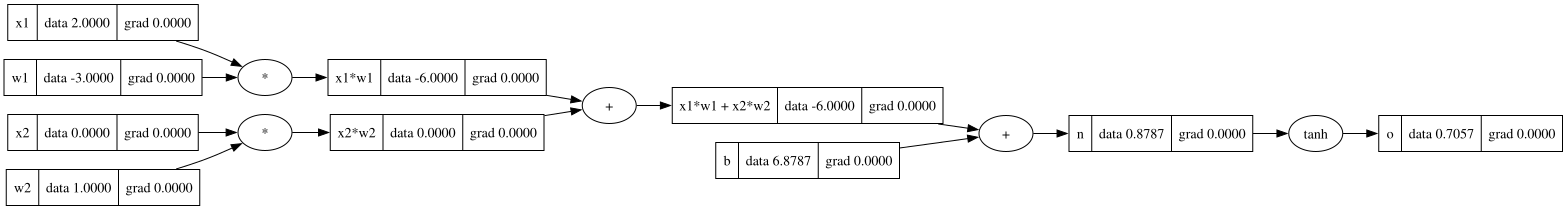

In [50]:
draw_dot(o)

In [51]:
o.grad = 1

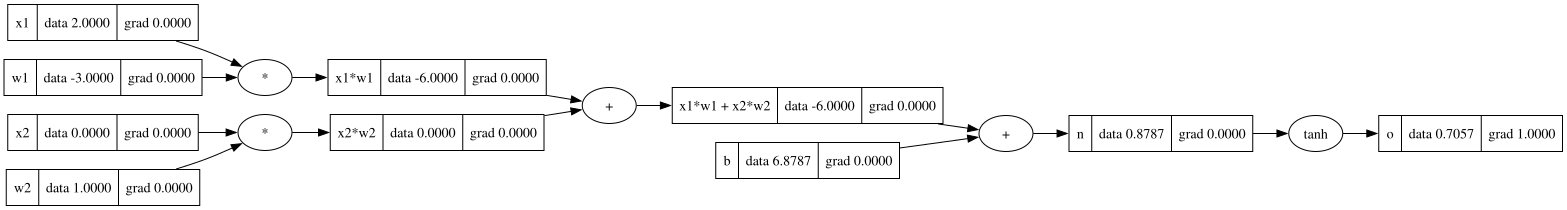

In [52]:
draw_dot(o)

In [53]:
o._backward() # to automatic calculate backpropogation of o

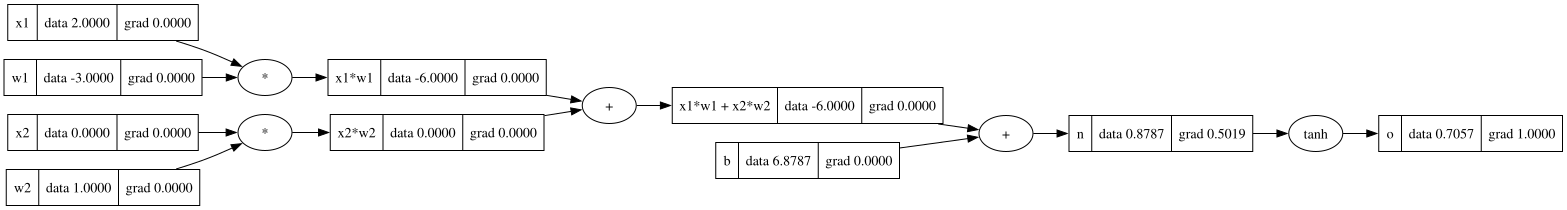

In [54]:
draw_dot(o)

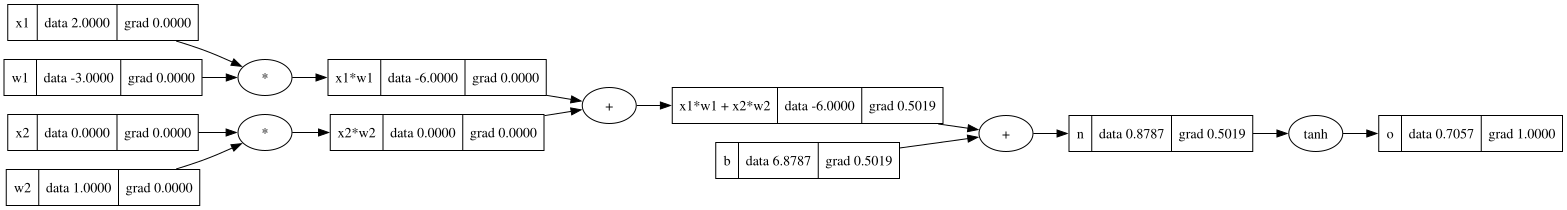

In [55]:
n._backward() # to automatic calculate backpropogation of n
draw_dot(o)

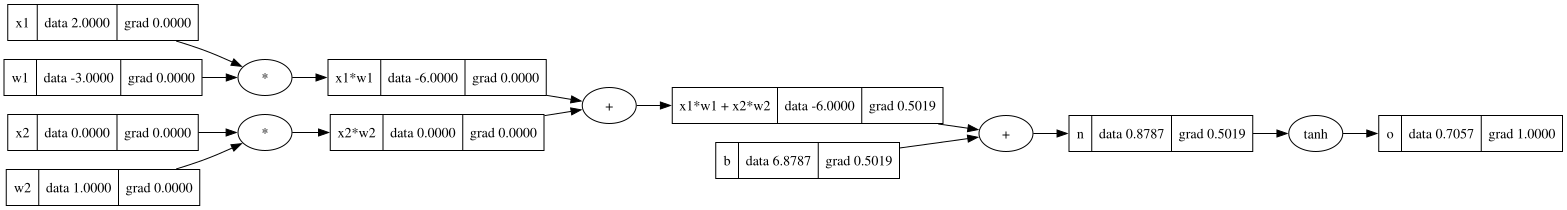

In [56]:
b._backward() # to automatic calculate backpropogation of b
draw_dot(o) # b will not show any changes as b is a leaf node and we set b as none for leaf node (empty function)

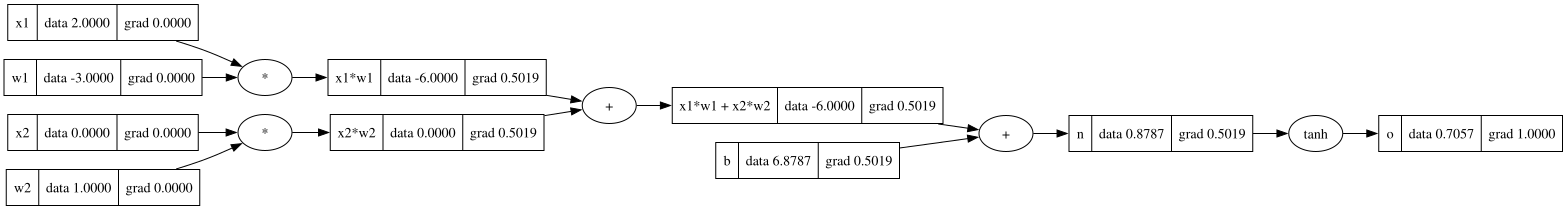

In [57]:
x1w1x2w2._backward() # to automatic calculate backpropogation of x1w1x2w2
draw_dot(o)

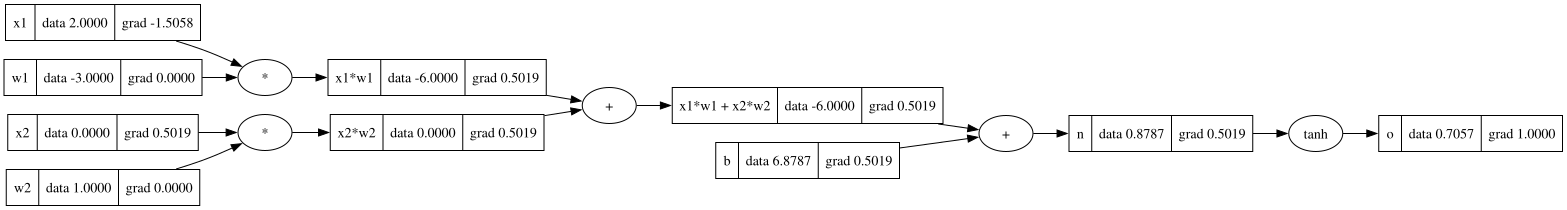

In [58]:
x1w1._backward()
x2w2._backward() # to automatic calculate backpropogation of x1w1x2w2
draw_dot(o)

In [59]:
o.grad = 1.0 

topo = []
visited = set()
def build_topo(v):
    if v not in visited:
        visited.add(v)
        for child in v._prev:
            build_topo(child)
        topo.append(v)
build_topo(o)

for node in reversed(topo):
    node._backward()

In [60]:
topo = []
visited = set()
def build_topo(v):
    if v not in visited:
        visited.add(v)
        for child in v._prev:
            build_topo(child)
        topo.append(v)
build_topo(o)
topo            

[value(data=2.0),
 value(data=-3.0),
 value(data=-6.0),
 value(data=0.0),
 value(data=1.0),
 value(data=0.0),
 value(data=-6.0),
 value(data=6.8786564646),
 value(data=0.8786564645999997),
 value(data=0.7057456081105479)]

In [61]:
class value:

    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self._prev = set(_children)
        self._op = _op
        self.label = label
        self.grad = 0.0
        self._backward = lambda: None

    def __repr__(self):
        return f"value(data={self.data})"

    # Addition
    def __add__(self, other):
        out = value(self.data + other.data, (self, other), '+')

        def _backward():
            self.grad += out.grad
            other.grad += out.grad

        out._backward = _backward
        return out

    # Multiplication
    def __mul__(self, other):
        out = value(self.data * other.data, (self, other), '*')

        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad

        out._backward = _backward
        return out

    # Negation
    def __neg__(self):
        return self * value(-1)

    # Subtraction
    def __sub__(self, other):
        return self + (-other)

    # Power
    def __pow__(self, other):
        assert isinstance(other, (int, float))

        out = value(
            self.data ** other,
            (self,),
            f'**{other}'
        )

        def _backward():
            self.grad += (
                other * self.data ** (other - 1)
            ) * out.grad

        out._backward = _backward
        return out

    # Tanh activation
    def tanh(self):
        x = self.data

        t = (math.exp(2*x) - 1) / (math.exp(2*x) + 1)

        out = value(t, (self,), 'tanh')

        def _backward():
            self.grad += (1 - t**2) * out.grad

        out._backward = _backward
        return out

    # Backpropagation
    def backward(self):

        topo = []
        visited = set()

        def build_topo(v):
            if v not in visited:
                visited.add(v)

                for child in v._prev:
                    build_topo(child)

                topo.append(v)

        build_topo(self)

        # Start gradient of output with 1
        self.grad = 1.0

        # Traverse graph backwards
        for node in reversed(topo):
            node._backward()

In [62]:
import torch

## # Doing the same thing BUT in PYTORCH 

In [63]:
import torch

x1 = torch.Tensor([2.0]).double()
x2 = torch.Tensor([0.0]).double()
w1 = torch.Tensor([-3.0]).double()
w2 = torch.Tensor([1.0]).double()
b = torch.Tensor([6.88137358701954321]).double()

x1.requires_grad = True
x2.requires_grad = True
w1.requires_grad = True
w2.requires_grad = True
b.requires_grad = True

n = x1 * w1 + x2 * w2 + b
o = torch.tanh(n)

print(o.data.item())
o.backward()

print("---")
print("x2", x2.grad.item())
print("w2", w2.grad.item())
print("x1", x1.grad.item())
print("w1", w1.grad.item())

0.7071066904050358
---
x2 0.5000001283844369
w2 0.0
x1 -1.5000003851533106
w1 1.0000002567688737


# PyTorch Autograd — Understanding the Code

This code is the **PyTorch version of the Micrograd example**.

The main purpose is to understand how PyTorch automatically builds the computation graph and calculates gradients using `autograd`.

---

## 1. Import PyTorch

```python
import torch
```

`torch` is the main PyTorch library.

We use it to create tensors, perform mathematical operations, and calculate gradients.

---

## 2. Creating the Inputs, Weights, and Bias

```python
x1 = torch.Tensor([2.0]).double()

x2 = torch.Tensor([0.0]).double()

w1 = torch.Tensor([-3.0]).double()

w2 = torch.Tensor([1.0]).double()

b = torch.Tensor([6.88137358701954321]).double()
```

Here we have:

$$
x_1=2
$$

$$
x_2=0
$$

$$
w_1=-3
$$

$$
w_2=1
$$

$$
b=6.88137358701954321
$$

These represent the **inputs, weights, and bias** of a simple neuron.

`.double()` converts the tensor to **64-bit floating-point (`float64`)**.

---

## 3. Enabling Gradient Tracking

```python
x1.requires_grad = True
x2.requires_grad = True

w1.requires_grad = True
w2.requires_grad = True

b.requires_grad = True
```

`requires_grad=True` tells PyTorch:

> "Track all operations involving this tensor because I will need its gradient later."

After the backward pass, PyTorch will store the gradients in:

```python
x1.grad
x2.grad
w1.grad
w2.grad
b.grad
```

For example:

$$
x_1.grad=\frac{\partial o}{\partial x_1}
$$

---

## 4. Forward Pass — Linear Combination

```python
n = x1 * w1 + x2 * w2 + b
```

Mathematically:

$$
n=x_1w_1+x_2w_2+b
$$

Substituting the values:

$$
n=(2)(-3)+(0)(1)+6.88137358701954321
$$

$$
n=-6+0+6.88137358701954321
$$

$$
\boxed{n=0.88137358701954321}
$$

This is the **pre-activation value** of the neuron.

---

## 5. Applying `tanh`

```python
o = torch.tanh(n)
```

The activation function is:

$$
o=\tanh(n)
$$

Therefore:

$$
o=\tanh(0.88137358701954321)
$$

which gives approximately:

$$
\boxed{o=0.7071067811865476}
$$

So the output is approximately:

```text
0.7071067811865476
```

---

## 6. Printing the Output

```python
print(o.data.item())
```

### `.data`

Accesses the underlying tensor data.

### `.item()`

Converts a single-element tensor into a normal Python number.

So instead of:

```text
tensor([0.7071])
```

we get:

```text
0.7071067811865476
```

> In modern PyTorch code, `.item()` is generally preferred for extracting a value. Direct use of `.data` is discouraged.

---

## 7. Starting Backpropagation

```python
o.backward()
```

This is the most important line.

It tells PyTorch:

> Start from `o` and calculate gradients backward through the entire computation graph.

Conceptually:

```text
x1 ──┐
     × ──┐
w1 ──┘   │
         +
x2 ──┐   │
     × ──┘── n ── tanh ── o
w2 ──┘
         
b ─────────┘
```

The backward pass goes in the opposite direction:

```text
o
↓
tanh
↓
n
↓
x1, w1, x2, w2, b
```

PyTorch automatically applies the **chain rule**.

---

## 8. Gradient of `tanh`

We know:

$$
o=\tanh(n)
$$

The derivative is:

$$
\frac{\partial o}{\partial n}=1-o^2
$$

Since:

$$
o\approx0.707106781
$$

we get:

$$
\frac{\partial o}{\partial n}
=
1-(0.707106781)^2
$$

$$
\boxed{\frac{\partial o}{\partial n}=0.5}
$$

---

## 9. Gradient of `x1`

We have:

$$
n=x_1w_1+x_2w_2+b
$$

Therefore:

$$
\frac{\partial n}{\partial x_1}=w_1
$$

Using the chain rule:

$$
\frac{\partial o}{\partial x_1}
=
\frac{\partial o}{\partial n}
\frac{\partial n}{\partial x_1}
$$

$$
=(0.5)(-3)
$$

Therefore:

$$
\boxed{\frac{\partial o}{\partial x_1}=-1.5}
$$

So:

```python
x1.grad.item()
```

gives:

```text
-1.5
```

---

## 10. Gradient of `w1`

Similarly:

$$
\frac{\partial n}{\partial w_1}=x_1
$$

Therefore:

$$
\frac{\partial o}{\partial w_1}
=
\frac{\partial o}{\partial n}
\frac{\partial n}{\partial w_1}
$$

$$
=(0.5)(2)
$$

$$
\boxed{\frac{\partial o}{\partial w_1}=1.0}
$$

So:

```python
w1.grad.item()
```

gives:

```text
1.0
```

---

## 11. Gradient of `x2`

Since:

$$
\frac{\partial n}{\partial x_2}=w_2
$$

we get:

$$
\frac{\partial o}{\partial x_2}
=
\frac{\partial o}{\partial n}
\frac{\partial n}{\partial x_2}
$$

$$
=(0.5)(1)
$$

Therefore:

$$
\boxed{\frac{\partial o}{\partial x_2}=0.5}
$$

So:

```python
x2.grad.item()
```

gives:

```text
0.5
```

---

## 12. Gradient of `w2`

Since:

$$
\frac{\partial n}{\partial w_2}=x_2
$$

and:

$$
x_2=0
$$

we get:

$$
\frac{\partial o}{\partial w_2}
=
(0.5)(0)
$$

Therefore:

$$
\boxed{\frac{\partial o}{\partial w_2}=0}
$$

So:

```python
w2.grad.item()
```

gives:

```text
0.0
```

---

## 13. Final Output

The code prints approximately:

```text
0.7071067811865476
---
x2 0.5
w2 0.0
x1 -1.5
w1 1.0
```

The gradients are:

| Variable | Gradient |
|---|---:|
| $x_1$ | $-1.5$ |
| $x_2$ | $0.5$ |
| $w_1$ | $1.0$ |
| $w_2$ | $0$ |
| $b$ | $0.5$ |

---

# 14. How This Connects to Micrograd

This is essentially what we implemented manually in Micrograd.

| Micrograd | PyTorch |
|---|---|
| `Value` | `Tensor` |
| `.data` | Tensor value |
| `.grad` | `.grad` |
| `_prev` | Autograd graph |
| `_op` | Operation metadata |
| `_backward()` | Autograd's backward rules |
| `topo[]` | Internal graph traversal |
| `o.grad = 1.0` | `.backward()` starts from scalar output |
| `v._backward()` | PyTorch executes backward operations |

In Micrograd we explicitly wrote:

```python
o.grad = 1.0

for v in reversed(topo):
    v._backward()
```

In PyTorch we simply write:

```python
o.backward()
```

PyTorch handles the graph traversal and gradient calculations internally.

---

# 15. The Most Important Concept

`_backward()` and `topo[]` had **different jobs** in Micrograd.

### `_backward()`

Answers:

> **HOW do I calculate the local gradient?**

### `topo[]`

Answers:

> **WHEN should I calculate each gradient?**

PyTorch hides both mechanisms behind:

```python
o.backward()
```

So:

$$
\boxed{\text{Micrograd = Autograd mechanics exposed}}
$$

$$
\boxed{\text{PyTorch = Autograd mechanics automated}}
$$

---

# Technical Interview Q&A

### Q1. What is `requires_grad=True`?

**Answer:** It tells PyTorch to track operations on that tensor so that gradients can be calculated during backpropagation.

### Q2. What does `o.backward()` do?

**Answer:** It performs reverse-mode automatic differentiation through the computation graph and stores the calculated gradients in the `.grad` attributes of the tensors.

### Q3. What is `x1.grad`?

**Answer:**

$$
x_1.grad=\frac{\partial o}{\partial x_1}
$$

It represents how much the output $o$ changes with respect to $x_1$.

### Q4. Why is `w2.grad = 0`?

**Answer:** Because $x_2=0$ and:

$$
\frac{\partial n}{\partial w_2}=x_2=0
$$

Therefore:

$$
\frac{\partial o}{\partial w_2}=0
$$

### Q5. What is the difference between Micrograd and PyTorch Autograd?

**Answer:** Micrograd manually implements the computation graph, local backward functions, topological ordering, and gradient propagation. PyTorch's Autograd automatically handles these processes.

### Q6. Why do we need the chain rule?

**Answer:** Because the output depends on variables through multiple operations. The chain rule allows us to propagate gradients through each operation.

$$
\boxed{
\frac{\partial o}{\partial x}
=
\frac{\partial o}{\partial y}
\frac{\partial y}{\partial x}
}
$$

In [64]:
torch.Tensor([[1,2,3],[4,5,6]])

tensor([[1., 2., 3.],
        [4., 5., 6.]])

In [65]:
torch.Tensor([[1,2,3],[4,5,6]]).shape

torch.Size([2, 3])

In [66]:
o

tensor([0.7071], dtype=torch.float64, grad_fn=<TanhBackward0>)

In [67]:
o.item()


0.7071066904050358

## # FOR Single Neuron

In [68]:
import random

In [69]:
class Neuron:
    def __init__(self,nin):
        self.w = [value(random.uniform(-1,1)) for _ in range(nin)]
        self.b = value(random.uniform(-1,1))


    def __call__(self, x):
        # w * x + b
        act = sum((wi*xi for wi,xi in zip(self.w,x)), self.b)
        out = act.tanh()
        return out 
    def parameters(self):
        return self.w + [self.b]    
x = [value(3.0),value(5.0)]  
n = Neuron(2)
n(x)

value(data=-0.7171721284689438)

# Neuron Class

This class represents **one artificial neuron**.

A neuron basically does:

$$
\boxed{output=\tanh(w_1x_1+w_2x_2+b)}
$$

---

## 1. `__init__()` — Creating the Neuron

```python
class Neuron:
    def __init__(self, nin):
        self.w = [value(random.uniform(-1,1)) for _ in range(nin)]
        self.b = value(random.uniform(-1,1))
```

### `nin`

`nin` means **number of inputs**.

Here:

```python
n = Neuron(2)
```

So the neuron has **2 inputs**.

Therefore it creates:

```text
w = [w1, w2]
b = bias
```

The weights and bias are initialized randomly between:

$$
-1 \leq w,b \leq 1
$$

Each random number is wrapped inside `value()` so that Micrograd can track its gradient.

---

## 2. `__call__()` — Forward Pass

```python
def __call__(self, x):
    # w * x + b
    act = sum((wi*xi for wi,xi in zip(self.w,x)), self.b)
    out = act.tanh()
    return out
```

This is what happens when we write:

```python
n(x)
```

### Step 1: Multiply weights and inputs

```python
wi * xi
```

For two inputs:

$$
w_1x_1+w_2x_2
$$

### Step 2: Add bias

```python
self.b
```

So:

$$
act=w_1x_1+w_2x_2+b
$$

### Step 3: Apply activation function

```python
out = act.tanh()
```

Therefore:

$$
out=\tanh(act)
$$

So the complete neuron is:

$$
\boxed{out=\tanh(w_1x_1+w_2x_2+b)}
$$

---

## 3. `zip(self.w, x)`

We have:

```python
x = [value(3.0), value(5.0)]
```

and the neuron has:

```text
self.w = [w1, w2]
```

`zip()` pairs them:

```text
w1 ↔ x1
w2 ↔ x2
```

Then:

```python
wi * xi
```

calculates:

```text
w1*x1
w2*x2
```

---

## 4. Why `sum(..., self.b)`?

This:

```python
sum((wi*xi for wi,xi in zip(self.w,x)), self.b)
```

is essentially:

```python
self.b + self.w[0]*x[0] + self.w[1]*x[1]
```

So:

$$
act=w_1x_1+w_2x_2+b
$$

The second argument of `sum()`:

```python
self.b
```

is the **starting value**.

---

## 5. Creating and Calling the Neuron

```python
x = [value(3.0), value(5.0)]

n = Neuron(2)

n(x)
```

Here:

```text
x
↓
[3.0, 5.0]
↓
Neuron
↓
Random weights + bias
↓
w1*x1 + w2*x2 + b
↓
tanh()
↓
output
```

### In one line:

$$
\boxed{
x=[3,5]
\rightarrow
w_1(3)+w_2(5)+b
\rightarrow
\tanh()
\rightarrow
output
}
$$

### Key takeaway

> **A neuron takes inputs, multiplies them by weights, adds a bias, and passes the result through an activation function.**

$$
\boxed{Neuron=\tanh(w\cdot x+b)}
$$

## Technical Interview Q&A

### Q1. What is a neuron?

**Answer:** A neuron computes a weighted sum of inputs, adds a bias, and applies an activation function.

### Q2. What does `nin` mean?

**Answer:** `nin` means the number of inputs to the neuron. `Neuron(2)` creates two weights.

### Q3. Why are weights initialized randomly?

**Answer:** To break symmetry so that different neurons can learn different patterns during training.

### Q4. Why do we use `value()` around the weights and inputs?

**Answer:** Because Micrograd's `Value` object stores the value, computation graph, and gradient required for automatic differentiation.

## # NOW DOING FOR LAYER OF NEURONS

In [70]:

class layer :
    def __init__(self,nin,nout): 
        self.neurons = [Neuron(nin) for _ in range(nout)]

    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) == 1 else outs
    def parameters(self):
        return [p for neuron in self.neurons for p in neuron.parameters()]    
        
x = [value(3.0),value(5.0)]  
n = layer(5,7)
n(x)

[value(data=-0.9889792782348787),
 value(data=0.7337292970172844),
 value(data=-0.9262686120351795),
 value(data=-0.9992403302218995),
 value(data=0.9875705347476548),
 value(data=0.9775957559379734),
 value(data=-0.9469108653223742)]

# From Single Neuron → Layer → Neural Network

Yes — this is the **next step after the single neuron**.

Previously, we created **one neuron**:

```python
n = Neuron(2)
```

Now we are creating a **layer containing multiple neurons**.

---

## 1. Previous Step: Single Neuron

Our previous code was:

```python
x = [value(3.0), value(5.0)]

n = Neuron(2)

n(x)
```

This means:

```text
        x1 ──→ Neuron ──→ output
        x2 ──→
```

The neuron has:

- 2 inputs
- 2 weights
- 1 bias
- 1 output

Mathematically:

$$
output=\tanh(w_1x_1+w_2x_2+b)
$$

So:

$$
\boxed{2\ inputs \rightarrow 1\ neuron \rightarrow 1\ output}
$$

---

# 2. What Is a Layer?

A **layer** is simply a collection of multiple neurons.

Your code:

```python
class layer:
    def __init__(self, nin, nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]
```

Here:

- `nin` = number of inputs **to each neuron**
- `nout` = number of neurons **in the layer**

For example:

```python
layer(5, 7)
```

means:

$$
\boxed{5\ inputs \rightarrow 7\ neurons}
$$

So we create:

```text
Neuron 1
Neuron 2
Neuron 3
Neuron 4
Neuron 5
Neuron 6
Neuron 7
```

Each neuron receives the **same 5 inputs**, but each neuron has its own weights and bias.

---

# 3. Why Do We Need Multiple Neurons?

A single neuron produces only **one output**.

But a layer can produce multiple outputs.

For example:

```text
                 ┌──→ Neuron 1 ──→ output 1
                 │
input 1 ─────────┼──→ Neuron 2 ──→ output 2
input 2 ─────────┼──→ Neuron 3 ──→ output 3
input 3 ─────────┼──→ Neuron 4 ──→ output 4
input 4 ─────────┼──→ ...
input 5 ─────────┼──→ Neuron 7 ──→ output 7
```

Therefore:

$$
\boxed{5\ inputs \rightarrow 7\ neurons \rightarrow 7\ outputs}
$$

---

# 4. Understanding This Line

```python
self.neurons = [Neuron(nin) for _ in range(nout)]
```

Suppose:

```python
layer(5, 7)
```

Then:

```python
range(7)
```

means we repeat 7 times:

```python
Neuron(5)
Neuron(5)
Neuron(5)
Neuron(5)
Neuron(5)
Neuron(5)
Neuron(5)
```

So:

```python
self.neurons
```

contains **7 neurons**.

Each neuron has:

```text
5 weights + 1 bias
```

Therefore the complete layer has:

$$
7\times5=35\ weights
$$

and:

$$
7\ biases
$$

Total trainable parameters:

$$
35+7=\boxed{42}
$$

---

# 5. The `__call__()` of the Layer

```python
def __call__(self, x):
    outs = [n(x) for n in self.neurons]
    return outs
```

When we do:

```python
n(x)
```

the layer sends the **same input `x` to every neuron**.

Conceptually:

```text
              ┌──→ Neuron 1 ──→ output 1
              │
              ├──→ Neuron 2 ──→ output 2
              │
x ────────────┼──→ Neuron 3 ──→ output 3
              │
              ├──→ ...
              │
              └──→ Neuron 7 ──→ output 7
```

Then:

```python
outs = [n(x) for n in self.neurons]
```

collects all 7 outputs.

So:

```python
return outs
```

returns:

```text
[output1, output2, ..., output7]
```

---

# 6. Connecting This With Your Diagram

Your diagram represents a complete neural network:

```text
Input Layer
     ↓
Hidden Layer 1
     ↓
Hidden Layer 2
     ↓
Output Layer
```

The important idea is:

```text
Neuron
   ↓
Layer
   ↓
Multiple Layers
   ↓
Neural Network
```

We are currently moving from:

$$
\boxed{\text{Single Neuron}}
$$

to:

$$
\boxed{\text{Layer of Neurons}}
$$

We will then combine multiple layers to create the complete neural network shown in your image.

---

# 7. IMPORTANT: Your Current Code Has a Mismatch

You wrote:

```python
x = [value(3.0), value(5.0)]

n = layer(5, 7)

n(x)
```

There is a problem here.

Your input contains only **2 values**:

```python
x = [3.0, 5.0]
```

but you created each neuron with:

```python
Neuron(5)
```

which expects **5 inputs**.

So conceptually you are saying:

```text
Input → only 2 values

Neuron → expects 5 inputs
```

These don't match.

### If you want to test a layer with your current `x`:

Use:

```python
x = [value(3.0), value(5.0)]

n = layer(2, 7)

n(x)
```

Now:

$$
\boxed{2\ inputs \rightarrow 7\ neurons \rightarrow 7\ outputs}
$$

This is valid.

---

# 8. Relating It Directly to Your Diagram

Look at the **first hidden layer** in your diagram.

There are:

```text
3 input neurons
        ↓
4 neurons in hidden layer 1
```

Therefore that layer would conceptually be:

```python
layer(3, 4)
```

Meaning:

$$
\boxed{3\ inputs \rightarrow 4\ neurons}
$$

Then the next hidden layer has 4 neurons receiving the 4 outputs from the previous layer:

```python
layer(4, 4)
```

Meaning:

$$
\boxed{4\ inputs \rightarrow 4\ neurons}
$$

Finally, the output layer has one neuron receiving 4 inputs:

```python
layer(4, 1)
```

Meaning:

$$
\boxed{4\ inputs \rightarrow 1\ neuron}
$$

So your diagram can be represented conceptually as:

```text
Input
  ↓
layer(3, 4)
  ↓
layer(4, 4)
  ↓
layer(4, 1)
  ↓
Output
```

---

# 9. The Big Picture

We are building the neural network step-by-step:

### Step 1 — Single Neuron

```python
Neuron(2)
```

$$
2\ inputs \rightarrow 1\ neuron
$$

### Step 2 — Layer

```python
layer(2, 7)
```

$$
2\ inputs \rightarrow 7\ neurons
$$

### Step 3 — Multiple Layers

```text
Input
 ↓
Layer 1
 ↓
Layer 2
 ↓
Output Layer
```

### Step 4 — Complete Neural Network

This is exactly what your image represents.

---

# Key Takeaway

> **A neuron produces one output. A layer is a collection of neurons, so it produces multiple outputs. Multiple layers connected together form a neural network.**

$$
\boxed{
\text{Neuron}
\rightarrow
\text{Layer}
\rightarrow
\text{Multiple Layers}
\rightarrow
\text{Neural Network}
}
$$

For your current code:

```python
layer(5, 7)
```

means:

$$
\boxed{\text{5 inputs} \rightarrow \text{7 neurons} \rightarrow \text{7 outputs}}
$$

But because your current `x` has only 2 values, use:

```python
layer(2, 7)
```

for this particular test.

## Technical Interview Q&A

### Q1. What is a layer in a neural network?

**Answer:** A layer is a collection of neurons that receive the same input and produce multiple outputs.

### Q2. What does `layer(5, 7)` mean?

**Answer:** It creates a layer containing 7 neurons, where each neuron receives 5 inputs.

### Q3. Do all neurons in a layer have the same weights?

**Answer:** No. Each neuron has its own weights and bias, allowing different neurons to learn different patterns.

### Q4. What is the output size of `layer(5, 7)`?

**Answer:** The output contains 7 values because there are 7 neurons.

### Q5. How is a layer different from a neuron?

**Answer:** A neuron produces one output, while a layer contains multiple neurons and therefore produces multiple outputs.

# How Can 2 Inputs Produce 7 Neurons?

This is the key idea:

**You don't need 5 different input values to create 7 neurons.**

If you have only **2 input values**:

$$
x=[3,5]
$$

you can still create **any number of neurons** that each receive those same 2 inputs.

---

## 1. Example: 2 Inputs → 7 Neurons

```python
x = [value(3.0), value(5.0)]

n = layer(2, 7)
```

This means:

```text
                    ┌── Neuron 1
                    │
                    ├── Neuron 2
                    │
x1 = 3 ─────────────┼── Neuron 3
                    │
x2 = 5 ─────────────┼── Neuron 4
                    │
                    ├── Neuron 5
                    │
                    ├── Neuron 6
                    │
                    └── Neuron 7
```

**Every neuron receives the same 2 inputs**, but each neuron has its **own weights and bias**.

---

## 2. Each Neuron Has Different Weights

For example:

### Neuron 1

$$
o_1=\tanh(w_{11}x_1+w_{12}x_2+b_1)
$$

### Neuron 2

$$
o_2=\tanh(w_{21}x_1+w_{22}x_2+b_2)
$$

### Neuron 3

$$
o_3=\tanh(w_{31}x_1+w_{32}x_2+b_3)
$$

And so on until Neuron 7.

So although every neuron receives:

$$
x_1=3,\qquad x_2=5
$$

each neuron has different:

$$
w_1,w_2,b
$$

Therefore, they produce different outputs.

---

## 3. Think of It Like 7 Different Questions

You give the same information:

```text
x1 = 3
x2 = 5
```

to 7 different neurons.

But each neuron has learned different weights, so each one processes the information differently.

```text
             Same Inputs
              [3, 5]
                 │
       ┌─────────┼─────────┐
       ↓         ↓         ↓
    Neuron 1  Neuron 2  Neuron 3 ... Neuron 7
       ↓         ↓         ↓           ↓
      o1        o2        o3          o7
```

Therefore:

$$
\boxed{2\ inputs\rightarrow7\ neurons\rightarrow7\ outputs}
$$

is completely valid.

---

# 4. Where Did `layer(5,7)` Come From?

This is where your confusion is coming from.

When you write:

```python
n = layer(5, 7)
```

you are **not saying**:

> "I have 5 inputs, so somehow create them from 3 and 5."

You are saying:

> "I already have 5 input values, and I want 7 neurons to process them."

Therefore, if your current input is only:

```python
x = [3, 5]
```

then:

```python
layer(5, 7)
```

doesn't match.

You should use:

```python
layer(2, 7)
```

---

# 5. But What About Your Neural Network Diagram?

Your diagram has **3 input nodes**.

Then the first hidden layer has **4 neurons**.

So the first layer would be:

```python
layer(3, 4)
```

because:

$$
3\ inputs\rightarrow4\ neurons
$$

Then the next layer receives the **4 outputs** from the previous layer:

```python
layer(4, 4)
```

Then the output layer:

```python
layer(4, 1)
```

So the complete network is:

```text
3 inputs
   ↓
4 neurons
   ↓
4 neurons
   ↓
1 neuron
```

or:

$$
\boxed{
3\rightarrow4\rightarrow4\rightarrow1
}
$$

---

# 6. The Important Concept

There are **two completely different things**:

### `nin`

How many values each neuron receives.

### `nout`

How many neurons are present in the layer.

Therefore:

```python
layer(2, 7)
```

means:

$$
\boxed{2\ inputs\rightarrow7\ neurons}
$$

It does **NOT** mean:

$$
2\ inputs\rightarrow2\ neurons
$$

The number of inputs and number of neurons **do not have to be equal**.

### Final rule:

$$
\boxed{len(x)=nin}
$$

while:

$$
\boxed{nout=\text{number of neurons in the layer}}
$$

So with:

```python
x = [value(3.0), value(5.0)]
```

you can absolutely have:

```python
n = layer(2, 7)
```

and get **7 outputs from the same 2 inputs**.

## MLP (Multi-Layer Perceptron)
class is used to combine multiple layers into one complete neural network.



## Input Layer → Hidden Layer(s) → Output Layer

In [71]:
class MLP:
    def __init__(self,nin,nouts):
        sz = [nin]+nouts
        self.layers = [layer(sz[i],sz[i+1]) for i in range(len(nouts))]

    def __call__(self,x):
        for layer in self.layers:
            x = layer(x)
        return x    
    def parameters(self):

        
        return[p for layer in self.layers for p in layer.parameters()]
    
x = [value(3.0),value(5.0)]  
n = layer(5,7)
n(x)        


[value(data=-0.9998875794663171),
 value(data=0.9997977185493158),
 value(data=-0.9948307227451332),
 value(data=-0.9960764327173148),
 value(data=-0.9557438571292409),
 value(data=0.9857407682929868),
 value(data=0.6596503880138673)]

# MLP — Multi-Layer Perceptron

Now we combine **multiple layers** to create a complete neural network.

## 1. `MLP` Class

```python
class MLP:
    def __init__(self, nin, nouts):
        sz = [nin] + nouts
        self.layers = [layer(sz[i], sz[i+1]) for i in range(len(nouts))]
```

`nin` = number of inputs.

`nouts` = number of neurons in each layer.

For example:

```python
MLP(3, [4, 4, 1])
```

creates:

```text
3 inputs
   ↓
4 neurons
   ↓
4 neurons
   ↓
1 neuron
```

So:

$$
\boxed{3\rightarrow4\rightarrow4\rightarrow1}
$$

---

## 2. Understanding `sz`

```python
sz = [nin] + nouts
```

If:

```python
nin = 3
nouts = [4, 4, 1]
```

then:

```python
sz = [3, 4, 4, 1]
```

This tells us the size of every layer.

Then:

```python
layer(3, 4)
layer(4, 4)
layer(4, 1)
```

are automatically created.

---

## 3. Forward Pass

```python
def __call__(self, x):
    for layer in self.layers:
        x = layer(x)
    return x
```

The output of one layer becomes the input to the next layer:

```text
Input
 ↓
Layer 1
 ↓
Layer 2
 ↓
Layer 3
 ↓
Output
```

This is how we connect multiple layers together.

---

## 4. Important Correction in Your Test

You wrote:

```python
x = [value(3.0), value(5.0)]

n = layer(5, 7)
n(x)
```

But this is **testing a layer**, not your `MLP`.

Since `x` has 2 values, use:

```python
n = layer(2, 7)
```

To test the `MLP`, for example:

```python
x = [value(3.0), value(5.0)]

n = MLP(2, [7, 4, 1])

n(x)
```

This creates:

$$
\boxed{2\rightarrow7\rightarrow4\rightarrow1}
$$

### Big Picture

```text
Neuron → Layer → MLP
```

$$
\boxed{
\text{Neuron}
\rightarrow
\text{Layer}
\rightarrow
\text{Multiple Layers}
\rightarrow
\text{MLP}
}
$$

In [72]:

x = [value(3.0),value(5.0),value(-2.0),value(7.0)]

n = MLP(4, [2,4,6,1])
n(x)        


value(data=-0.13743965537516667)

# MLP Example — Correct Setup

```python
x = [value(3.0), value(5.0), value(-2.0), value(7.0)]

n = MLP(4, [2, 4, 6, 1])

n(x)
```

This is **correct** because:

```text
Input has 4 values
        ↓
MLP expects 4 inputs
```

## Network Structure

```text
4 Inputs
   ↓
2 Neurons   ← Hidden Layer 1
   ↓
4 Neurons   ← Hidden Layer 2
   ↓
6 Neurons   ← Hidden Layer 3
   ↓
1 Neuron    ← Output Layer
```

So the architecture is:

$$
\boxed{4\rightarrow2\rightarrow4\rightarrow6\rightarrow1}
$$

### What happens during `n(x)`?

The input:

```text
[3, 5, -2, 7]
```

goes through each layer sequentially:

```text
[3, 5, -2, 7]
        ↓
   Layer(4, 2)
        ↓
     2 outputs
        ↓
   Layer(2, 4)
        ↓
     4 outputs
        ↓
   Layer(4, 6)
        ↓
     6 outputs
        ↓
   Layer(6, 1)
        ↓
    1 final output
```

The important idea is:

> **The output of one layer becomes the input to the next layer.**

Therefore, this code creates a complete MLP with **3 hidden layers and 1 output layer**.

$$
\boxed{4\ inputs\rightarrow2\rightarrow4\rightarrow6\rightarrow1\ output}
$$

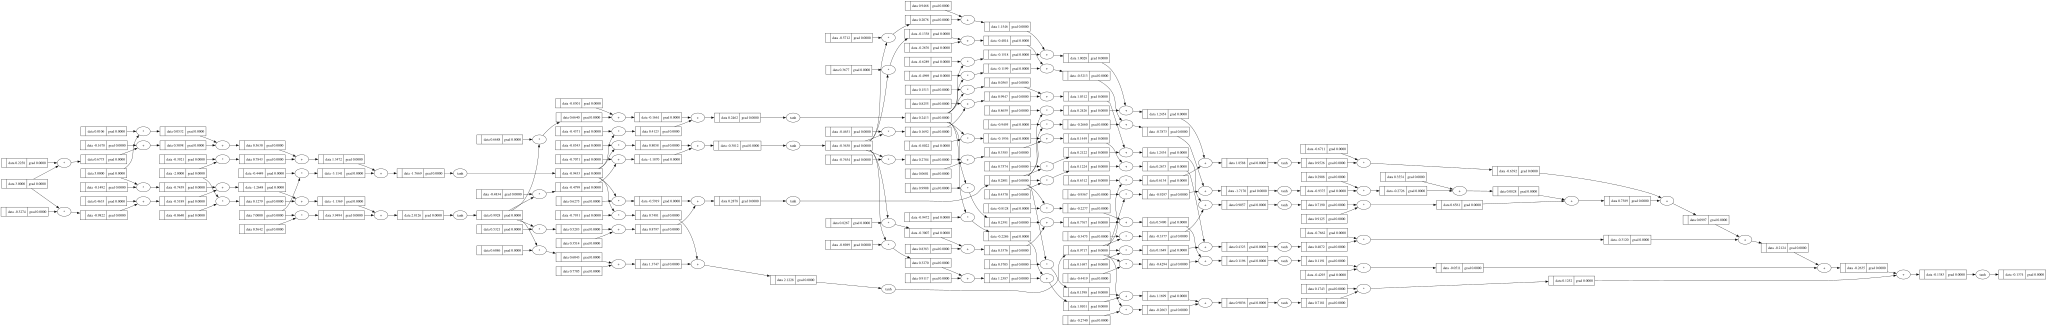

In [73]:
draw_dot(n(x))

# Final Micrograd Computation Graph

Yes 👍 This is the **final computation graph** you get after passing your input through the MLP.

Your network was:

$$
\boxed{4\rightarrow2\rightarrow4\rightarrow6\rightarrow1}
$$

So the graph shows the complete flow:

```text
4 Inputs
   ↓
Layer 1: 2 neurons
   ↓
Layer 2: 4 neurons
   ↓
Layer 3: 6 neurons
   ↓
Output Layer: 1 neuron
   ↓
Final Output
```

The graph you generated contains all the individual `Value` objects and operations (`+`, `*`, `tanh`) involved in these calculations. The uploaded result shows this complete computation graph on page 1. :contentReference[oaicite:0]{index=0}

## What We Have Built Step-by-Step

```text
Value
  ↓
Neuron
  ↓
Layer
  ↓
MLP
  ↓
Computation Graph
```

### 1. `Value`

Stores:

```text
data
grad
_prev
_op
_backward()
```

### 2. `Neuron`

Performs:

$$
\tanh(w_1x_1+w_2x_2+\cdots+b)
$$

### 3. `Layer`

Combines multiple neurons:

$$
\text{inputs}\rightarrow\text{multiple neurons}\rightarrow\text{multiple outputs}
$$

### 4. `MLP`

Combines multiple layers:

$$
4\rightarrow2\rightarrow4\rightarrow6\rightarrow1
$$

### 5. `draw_dot()`

Finally, `draw_dot()` visualizes the **entire computation graph** created by the MLP.

So yes — **this is the big picture of what we have been building throughout Micrograd.**

> **We started with one `Value`, built neurons from Values, built layers from neurons, built an MLP from layers, and finally visualized the complete computation graph.**

# # Creating tiny dataset, Writing the loss function 

In [74]:
xs = [
    [value(2.0),value(3.0),value(-1.0)],
    [value(3.0),value(-1.0),value(0.5)],
    [value(0.5),value(1.0),value(1.0)],
    [value(1.0),value(1.0),value(-1.0)]
]
ys = [value(1.0),value(-1.0),value(-1.0),value(1.0)] #desired Targets

ypred = [n(x) for x in xs ]
ypred 

[value(data=0.17160964016541247),
 value(data=0.0706702448474393),
 value(data=-0.17283995108057787),
 value(data=0.08216140484789287)]

In [75]:
ypred # now we can see that wee are getting more closer to our targeted value 

[value(data=0.17160964016541247),
 value(data=0.0706702448474393),
 value(data=-0.17283995108057787),
 value(data=0.08216140484789287)]

# Creating Tiny Dataset & Getting Predictions

We are now preparing a **small dataset** for our MLP and getting its predictions.

## 1. Input Data — `xs`

```python
xs = [
    [value(2.0), value(3.0), value(-1.0)],
    [value(3.0), value(-1.0), value(0.5)],
    [value(0.5), value(1.0), value(1.0)],
    [value(1.0), value(1.0), value(-1.0)]
]
```

There are **4 training examples**.

Each example has **3 input values**:

```text
Example 1 → [ 2,  3, -1]
Example 2 → [ 3, -1,  0.5]
Example 3 → [ 0.5, 1, 1]
Example 4 → [ 1, 1, -1]
```

So:

$$
\boxed{4\ examples,\;3\ inputs\ each}
$$

We use `value()` because these inputs need to be part of Micrograd's computation graph.

---

## 2. Target Values — `ys`

```python
ys = [
    value(1.0),
    value(-1.0),
    value(-1.0),
    value(1.0)
]
```

These are the **desired outputs** (ground-truth).

```text
Input 1 → Target =  1
Input 2 → Target = -1
Input 3 → Target = -1
Input 4 → Target =  1
```

So every input example has one corresponding target:

$$
\boxed{xs_i \leftrightarrow ys_i}
$$

---

## 3. Getting Predictions — `ypred`

```python
ypred = [n(x) for x in xs]
```

Here, `n` is our MLP.

We send **each training example** through the MLP.

For example:

```text
x₁ = [2, 3, -1]
        ↓
       MLP
        ↓
     prediction₁
```

Then the same happens for all 4 examples.

Equivalent code:

```python
ypred = []

for x in xs:
    prediction = n(x)
    ypred.append(prediction)
```

Therefore:

$$
\boxed{ypred=[n(x_1),n(x_2),n(x_3),n(x_4)]}
$$

---

## 4. Your Current Output

Your MLP currently produces:

```text
[
 value(data=-0.0729975),
 value(data=-0.2862733),
 value(data=0.1862928),
 value(data=-0.1521551)
]
```

So approximately:

$$
ypred=[-0.073,-0.286,0.186,-0.152]
$$

These are the **initial predictions** of the network.

They don't match the targets yet:

| Input | Prediction | Target |
|---|---:|---:|
| $x_1$ | $-0.073$ | $1$ |
| $x_2$ | $-0.286$ | $-1$ |
| $x_3$ | $0.186$ | $-1$ |
| $x_4$ | $-0.152$ | $1$ |

That's expected because the MLP's weights and biases were initialized randomly.

---

# What Are We Doing Now?

So far:

```text
xs
↓
Input examples

MLP
↓
Predictions

ys
↓
Correct answers
```

Now we need to compare:

$$
\boxed{ypred\quad vs\quad ys}
$$

to find out **how wrong the network is**.

That gives us the **loss**.

```text
Input data
    ↓
   MLP
    ↓
 Predictions
    ↓
 Compare with Targets
    ↓
   Loss
```

> **This step is simply: create the training examples, define their correct answers, and let the MLP make its initial predictions.**

In [76]:
# individual losses 
individual_loss = [(yout - ygt)**2 for ygt , yout in zip(ys,ypred) ] # ygt = y ground trougth 
print(individual_loss)

[value(data=0.6862305882668774), value(data=1.1463347732016755), value(data=0.6841937465283809), value(data=0.8424276867507935)]


These are the **individual losses for the 4 training examples**.

## What happened?

For each example:

$$
\boxed{loss=(y_{out}-y_{gt})^2}
$$

So:

```text
Example 1 → loss = 1.1513
Example 2 → loss = 0.5094
Example 3 → loss = 1.4073
Example 4 → loss = 1.3275
```

Each loss is a `value` object, which is important because Micrograd needs to keep these calculations inside the **computation graph** for backpropagation later.

## Why "individual" losses?

Because we calculated a separate loss for every training example:

```text
4 examples
   ↓
4 predictions
   ↓
4 individual losses
```

Now we need to combine these individual losses into **one total loss**.

Conceptually:

$$
\boxed{
L_{total}=L_1+L_2+L_3+L_4
}
$$

This single total loss will then be used for:

```text
Total Loss
    ↓
Backward Pass
    ↓
Gradients
    ↓
Update weights
```

> **So this step successfully calculates how wrong the MLP is for each individual training example.**

In [77]:
Total_loss = sum([(yout - ygt)**2 for ygt , yout in zip(ys,ypred) ],value(0))
Total_loss

value(data=3.3591867947477274)

In [78]:
ypred = [n(x) for x in xs ]
Total_loss = sum([(yout - ygt)**2 for ygt , yout in zip(ys,ypred) ],value(0))
Total_loss

value(data=3.3591867947477274)

## What happened?

We had 4 individual losses:

$$
L_1,\;L_2,\;L_3,\;L_4
$$

Now we added them:

$$
L_{total}=L_1+L_2+L_3+L_4
$$

So:

$$
\boxed{L_{total}\approx4.3955}
$$

This **single `value` object** is now our total loss.

### Why is this important?

We will use this one value for the backward pass:

```text
Individual losses
      ↓
   Total Loss
      ↓
  Backpropagation
      ↓
   Gradients
      ↓
 Update weights
```

So you've now completed the **forward pass + loss calculation**.

> **Next step: use `Total_loss.backward()` / implement backward propagation in Micrograd so we can find how every weight and bias contributed to this loss.**

In [79]:
n.layers[1].neurons[1].w[1].grad

0.0

In [80]:

n = MLP(3, [4, 4, 1])


### 2. Create predictions


ypred = [n(x) for x in xs]


### 3. Calculate total loss


Total_loss = sum(
    [(yout - ygt)**2 for ygt, yout in zip(ys, ypred)],
    value(0)
)

Total_loss


# ### 4. NOW run backward


Total_loss.backward()





n.layers[0].neurons[0].w[0].grad



-0.25583198241319793

In [81]:

n.layers[0].neurons[0].w[0].data

-0.13906135531415043

In [82]:
n.parameters()

[value(data=-0.13906135531415043),
 value(data=0.819958358686333),
 value(data=-0.12155072152133672),
 value(data=-0.8205389833020011),
 value(data=-0.8594918925635098),
 value(data=0.39343101236862155),
 value(data=0.0351076185058552),
 value(data=-0.7117765573103199),
 value(data=-0.4679220229400183),
 value(data=0.8196860325911011),
 value(data=-0.056142160958132514),
 value(data=-0.25373360830198877),
 value(data=-0.305722646451551),
 value(data=-0.6677556251622303),
 value(data=0.7154749496531332),
 value(data=-0.3356277181398908),
 value(data=0.3767093118463536),
 value(data=0.8137996261294287),
 value(data=-0.5036285431206622),
 value(data=-0.7411133921125532),
 value(data=0.6568272200871725),
 value(data=-0.5593241967506111),
 value(data=0.0655016441416223),
 value(data=0.12569661389004527),
 value(data=0.20412135838911327),
 value(data=0.39644758013757087),
 value(data=-0.44094691776238637),
 value(data=0.3329096430595868),
 value(data=-0.9750812728493086),
 value(data=-0.0544

In [83]:
for p in n.parameters():
    p.data += -0.01 * p.grad

# Parameter Update — Gradient Descent

```python
for p in n.parameters():
    p.data += -0.01 * p.grad
```

This **updates every weight and bias** of the network.

Formula:

$$
\boxed{p = p - \eta \frac{\partial L}{\partial p}}
$$

where:

- `p.data` → current parameter
- `p.grad` → gradient of loss
- `0.01` → learning rate $\eta$

### Why `-`?

The gradient points toward **increasing loss**, so we move in the opposite direction to **reduce loss**.

```text
Gradient → increase loss
    ↑
    |
    ↓
Opposite direction → reduce loss
```

So this is the step where the network **actually learns**.

In [84]:

n.layers[0].neurons[0].w[0].data # now we can see that the weight  is decreased from 0.3264792772080636 to 0.3125330730376144

-0.13650303549001844

In [85]:
ypred = [n(x) for x in xs ]
Total_loss = sum([(yout - ygt)**2 for ygt , yout in zip(ys,ypred) ],value(0))
Total_loss

value(data=1.2027765451532337)

In [86]:
ypred = [n(x) for x in xs ]
Total_loss = sum([(yout - ygt)**2 for ygt , yout in zip(ys,ypred) ],value(0))
Total_loss

value(data=1.2027765451532337)

In [87]:
# 1. Forward pass
ypred = [n(x) for x in xs]

# 2. Calculate loss
Total_loss = sum(
    [(yout - ygt)**2 for ygt, yout in zip(ys, ypred)],
    value(0)
)

print("Before:", Total_loss.data)




Before: 1.2027765451532337


In [88]:

for k in range(120):
    # 3. Reset gradients
    for p in n.parameters():
        p.grad = 0.0
    
    # 4. Backpropagation
    Total_loss.backward()

    # 5. Update parameters
    for p in n.parameters():
        p.data += -0.01 * p.grad


    # 6. Forward pass AGAIN
    ypred = [n(x) for x in xs]

    # 7. Calculate NEW loss
    Total_loss = sum(
        [(yout - ygt)**2 for ygt, yout in zip(ys, ypred)],
        value(0)
    )

    print("After:", Total_loss.data)

After: 1.0917860306374756
After: 0.9883098549601188
After: 0.8923238030752492
After: 0.8040855122435051
After: 0.723806436731333
After: 0.6514964458991923
After: 0.5869272548409012
After: 0.5296649053655692
After: 0.47913240274711877
After: 0.43467631058286094
After: 0.3956229889781899
After: 0.3613192426326852
After: 0.33115772884099565
After: 0.30459006386616916
After: 0.28113118284695365
After: 0.2603581151842077
After: 0.2419055904791872
After: 0.22546014146996574
After: 0.2107537620548121
After: 0.19755773784102293
After: 0.18567697170139005
After: 0.17494494172172484
After: 0.1652193199282726
After: 0.15637822082474045
After: 0.14831702020158394
After: 0.1409456742985304
After: 0.13418646914960175
After: 0.12797213486776865
After: 0.12224426680694349
After: 0.11695200331862277
After: 0.11205091732230349
After: 0.10750208571573061
After: 0.10327130660830888
After: 0.09932843945646075
After: 0.09564684747266473
After: 0.09220292526052412
After: 0.08897569759480141
After: 0.08594647

# What is happening in your code?

You have now implemented the **complete Gradient Descent training process**. 🎯

## Before Training

```python
ypred = [n(x) for x in xs]
```

➡️ Network makes predictions using the **current weights**.

```python
Total_loss = sum(...)
```

➡️ Calculates the initial loss.

Your result:

```text
Before: 6.008118422325971
```

So initially:

$$
L = 6.0081
$$

---

# Training Loop

```python
for k in range(120):
```

➡️ Repeat the learning process **120 times**.

### 1. Reset gradients

```python
for p in n.parameters():
    p.grad = 0.0
```

➡️ Remove gradients from the previous iteration.

### 2. Backpropagation

```python
Total_loss.backward()
```

➡️ Calculate the gradient of the loss for every weight and bias.

$$
\frac{\partial L}{\partial p}
$$

### 3. Update parameters

```python
for p in n.parameters():
    p.data += -0.01 * p.grad
```

➡️ Change every weight and bias using Gradient Descent.

$$
p \leftarrow p - 0.01\frac{\partial L}{\partial p}
$$

### 4. Forward pass again

```python
ypred = [n(x) for x in xs]
```

➡️ Use the **new weights/biases** to make new predictions.

### 5. Calculate new loss

```python
Total_loss = sum(...)
```

➡️ Check how good the new predictions are.

Your output shows:

```text
After: 5.6806
After: 5.3312
After: 4.9783
After: 4.6282
After: 4.2720
After: 3.9005
After: 3.5194
After: 3.1505
After: 2.8185
After: 2.5356
After: 2.3000
After: 2.1031
After: 1.9352
...
```

### What does this tell us?

```text
6.0081
   ↓
5.6806
   ↓
5.3312
   ↓
4.9783
   ↓
4.6282
   ↓
...
```

✅ **Loss is decreasing!**

That means your network is **learning successfully**.

---

## The whole idea

```text
Forward Pass
     ↓
Calculate Loss
     ↓
Reset Gradients
     ↓
Backward()
     ↓
Calculate Gradients
     ↓
Update Weights & Biases
     ↓
Forward Pass Again
     ↓
Calculate New Loss
     ↓
Repeat 120 times
```

**This is Gradient Descent training in Micrograd.** 🚀

In [89]:
ypred # after some more iteration we can achieve our target value 

[value(data=0.9600997301562654),
 value(data=-0.9888028152922307),
 value(data=-0.9087439804218629),
 value(data=0.897503804757606)]

# Classification in Micrograd — From Starting to Training

Just like we did for **prediction/regression**, now we build the complete pipeline for **classification**.

---

# 1. Classification Dataset

In classification, our target is a **class**, not a continuous number.

For binary classification, we can represent:

```text
Class 1 → +1
Class 2 → -1
```

Example:

```python
xs = [
    [2.0, 3.0],
    [1.0, -2.0],
    [-2.0, -1.0],
]

ys = [1, -1, 1]
```

Here:

- `xs` → input features
- `ys` → target classes

---

# 2. Create the Model

Just like before:

```python
model = MLP(2, [4, 4, 1])
```

Meaning:

```text
2 input features
      ↓
4 neurons
      ↓
4 neurons
      ↓
1 output score
```

The final output is a **score**, not necessarily a probability.

Example:

```text
+2.5 → positive class
-1.3 → negative class
```

---

# 3. Forward Pass

Give the inputs to the model:

```python
scores = [model(x) for x in xs]
```

Conceptually:

```text
Input
  ↓
Neural Network
  ↓
Score
```

---

# 4. Prediction

For binary classification:

```python
prediction = 1 if score > 0 else -1
```

So:

```text
score = +2.5 → +1
score = -0.8 → -1
```

The **sign of the score** determines the class.

---

# 5. Classification Loss — Hinge Loss

For our `+1/-1` classification setup, we use **hinge loss**:

$$
L_i = \max(0, 1-y_i s_i)
$$

where:

- $y_i$ = actual class (`+1` or `-1`)
- $s_i$ = model score

In Micrograd:

```python
losses = [(1 + -yi * score).relu()
          for yi, score in zip(ys, scores)]
```

### Example

Correct and confident:

```text
y = +1
score = +2
```

$$
L = \max(0,1-(1)(2))=0
$$

✅ Loss = 0

Wrong prediction:

```text
y = +1
score = -2
```

$$
L = \max(0,1-(1)(-2))=3
$$

❌ High loss

---

# 6. Average Data Loss

```python
data_loss = sum(losses) * (1.0 / len(losses))
```

Mathematically:

$$
L_{\text{data}}
=
\frac{1}{N}\sum_{i=1}^{N}L_i
$$

This gives the average classification error.

---

# 7. Regularization

We also add a small penalty for large weights:

```python
alpha = 1e-4

reg_loss = alpha * sum(
    p*p for p in model.parameters()
)
```

Mathematically:

$$
L_{\text{reg}}=\alpha\sum p^2
$$

This helps prevent excessively large parameters and overfitting.

---

# 8. Total Loss

```python
total_loss = data_loss + reg_loss
```

Therefore:

$$
\boxed{
L_{\text{total}}
=
L_{\text{data}}+L_{\text{reg}}
}
$$

This is the loss that we will backpropagate.

---

# 9. Accuracy

We check whether the sign of the prediction matches the sign of the target:

```python
accuracy = sum(
    (yi > 0) == (score.data > 0)
    for yi, score in zip(ys, scores)
)
```

Then:

$$
\text{Accuracy}
=
\frac{\text{correct predictions}}{N}
$$

Example:

```text
8 correct / 10 samples = 80%
```

---

# 10. Complete Loss Function

Conceptually:

```python
def loss():

    # Forward
    scores = [model(x) for x in xs]

    # Hinge loss
    losses = [
        (1 + -yi * score).relu()
        for yi, score in zip(ys, scores)
    ]

    # Data loss
    data_loss = sum(losses) * (1.0 / len(losses))

    # Regularization
    alpha = 1e-4
    reg_loss = alpha * sum(
        p*p for p in model.parameters()
    )

    # Total loss
    total_loss = data_loss + reg_loss

    return total_loss
```

---

# 11. Training

Now we repeatedly improve the model:

```python
for k in range(100):

    # Forward + loss
    total_loss = loss()

    # Reset gradients
    model.zero_grad()

    # Backpropagation
    total_loss.backward()

    # Update parameters
    for p in model.parameters():
        p.data += -learning_rate * p.grad
```

The process is:

```text
Input
 ↓
Forward Pass
 ↓
Scores
 ↓
Hinge Loss
 ↓
Backward()
 ↓
Gradients
 ↓
Update weights
 ↓
Repeat
```

---

# 12. Why ReLU/tanh/sigmoid?

### In our Micrograd example

We used:

```python
act.tanh()
```

because `tanh`:

$$
-1 \leq \tanh(x) \leq 1
$$

and our original targets were `-1` and `+1`.

It is also smooth and easy to understand when learning backpropagation.

### For large modern networks

Usually:

```text
Hidden layers → ReLU / ReLU-family
```

because they are efficient and work well in deep networks.

### Output depends on the problem

**Binary classification:**

```text
Output → Sigmoid → probability
```

with Binary Cross-Entropy.

**Multiclass classification:**

```text
Output → Softmax → probabilities
```

with Cross-Entropy.

**Karpathy's hinge-loss example:**

```text
Hidden layers → ReLU
Final layer → score
              ↓
          Hinge Loss
```

---

# Final Comparison

## Prediction / Regression

```text
Input
 ↓
Network
 ↓
Prediction
 ↓
MSE Loss
 ↓
Backward
 ↓
Update
```

## Classification

```text
Input
 ↓
Network
 ↓
Class Score
 ↓
Hinge Loss
 ↓
Backward
 ↓
Update
 ↓
Class Prediction
```

### Most important idea

**Regression asks:**

> "How close is my predicted number to the target?"

**Classification asks:**

> "Did I put the example on the correct side of the decision boundary?"

And training both follows the same fundamental process:

$$
\boxed{
\text{Forward}
\rightarrow
\text{Loss}
\rightarrow
\text{Backward}
\rightarrow
\text{Update}
\rightarrow
\text{Repeat}
}
$$